<a href="https://colab.research.google.com/github/SyChen94/colab/blob/main/GEMAS_Sphere_CI_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEMAS sphere-valued conditional-independence analysis

This notebook runs the spherical GEMAS application for the metric-space
conditional-independence paper. It is self-contained and automatically:

1. downloads the official GEMAS agricultural-soil archive;
2. removes the five all-zero quality-control records;
3. constructs the positive-sphere objects $X$, $Y$, and $W$;
4. forms the mixed product metric for $Z$;
5. runs repeated two-fold cross-fitting and local block-permutation calibration;
6. runs the known-truth semi-synthetic calibration and power experiment;
7. saves all tables, diagnostics, figures, seeds, and fold artifacts.

Run the cells from top to bottom. Start with `MODE = "quick"`. Quick mode checks
the pipeline and signal direction but has only 49 permutations, so its combined
$p$-values do not have sufficient resolution for the paper. After we inspect the
quick output, use paper mode for the final reported results.


In [1]:
%%writefile /content/GEMAS_Sphere_CI_Colab.py
#!/usr/bin/env python3
"""GEMAS sphere-valued conditional-independence analysis for Google Colab.

The script is self-contained: it downloads the official GEMAS shapefile archive,
reads the DBF table without a GIS dependency, constructs positive-sphere
compositions, runs repeated two-fold cross-fitting, and writes paper-oriented
tables and figures. It also includes a GEMAS-grounded semi-synthetic experiment
with a known conditional-independence null.

Recommended Colab workflow
---------------------------
1. Upload this file to Colab.
2. Run a small validation job:

       !python GEMAS_Sphere_CI_Colab.py --mode quick

3. Download /content/gemas_sphere_ci_output.zip and inspect it before running:

       !python GEMAS_Sphere_CI_Colab.py --mode paper

The paper mode is intentionally computationally demanding. Use
--skip-semisynthetic to run only the real-data analysis, or --analyses primary
to run only the pre-specified primary conditioning set.
"""

from __future__ import annotations

import argparse
import json
import math
import shutil
import struct
import time
import urllib.request
import warnings
import zipfile
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

try:
    import torch
except ImportError:  # The NumPy fallback keeps the script usable outside Colab.
    torch = None


if torch is None:
    def no_grad(function):
        return function
else:
    no_grad = torch.no_grad()


GEMAS_URL = (
    "https://gsi.geodata.gov.ie/downloads/Geochemistry/Data/"
    "IE_GSI_GEMAS_Geochemistry_Agricultural_Grazing_Land_Soil_EU_WGS84.zip"
)
DBF_FILENAME = "IE_GSI_GEMAS_Agricultural_Soil_Ap_Samples_AR_XRF_EU_WGS84.dbf"

OXIDE_COLUMNS = [
    "SIO2",
    "AL2O3",
    "FE2O3",
    "MGO",
    "CAO",
    "K2O",
    "NA2O",
    "TIO2",
    "P2O5",
]
X_COLUMNS = ["SIO2", "AL2O3", "FE2O3"]
Y_COLUMNS = ["CAO", "MGO", "K2O"]
W_COLUMNS = ["TIO2", "P2O5", "NA2O"]
NUMERIC_COLUMNS = ["XCOO", "YCOO", "ALT", "PH_CACL2", "TOC", "CEC"]
CATEGORICAL_COLUMNS = ["COUNTRY", "CLIMATE", "PM", "SOILCLASS", "SOILTYPE"]
DBF_COLUMNS = ["ID", *OXIDE_COLUMNS, *NUMERIC_COLUMNS, *CATEGORICAL_COLUMNS]

METHOD_SPECIFICATION = {
    "statistic": "generator-assisted MDF discrepancy",
    "integration_measure": "empirical law of generated conditionally independent copy points",
    "integration_pairs": "fixed off-diagonal ordered pairs sampled from copy points",
    "calibration": "uniform permutations within fixed mutual-k-neighbor Z-blocks",
    "block_target_size_rule": "max(3, round(sqrt(k)))",
    "generator_geometry": "ALR logistic-normal model mapped to the positive sphere",
    "generator_mean": "bootstrap ExtraTrees conditional mean",
    "generator_residuals": "OOB residual location and Ledoit-Wolf covariance with tail inflation",
}


@dataclass(frozen=True)
class AnalysisSpec:
    name: str
    use_location: bool
    numeric_names: tuple[str, ...]
    categorical_names: tuple[str, ...]


ANALYSIS_SPECS = {
    "reduced": AnalysisSpec(
        name="reduced",
        use_location=False,
        numeric_names=(),
        categorical_names=(),
    ),
    "primary": AnalysisSpec(
        name="primary",
        use_location=True,
        numeric_names=("ALT",),
        categorical_names=("CLIMATE", "PM", "SOILCLASS"),
    ),
    "extended": AnalysisSpec(
        name="extended",
        use_location=True,
        numeric_names=("ALT", "PH_CACL2", "TOC", "CEC"),
        categorical_names=("CLIMATE", "PM", "SOILCLASS"),
    ),
}


@dataclass(frozen=True)
class RunConfig:
    mode: str
    analyses: tuple[str, ...]
    random_seed: int
    real_repeats: int
    split_candidates: int
    m_profile: int
    b_permutation: int
    integration_pairs: int
    pair_batch_size: int
    k_neighbors: int
    generator_trees: int
    generator_min_leaf: int
    diagnostic_draws: int
    semi_enabled: bool
    semi_n: int
    semi_m_profile: int
    semi_b_permutation: int
    semi_integration_pairs: int
    semi_null_reps: int
    semi_alt_reps: int
    semi_rhos: tuple[float, ...]
    semi_k_values: tuple[int, ...]
    semi_rank: int
    semi_mean_strength: float


def mode_config(mode: str) -> RunConfig:
    if mode == "smoke":
        return RunConfig(
            mode=mode,
            analyses=("primary",),
            random_seed=20260906,
            real_repeats=1,
            split_candidates=8,
            m_profile=6,
            b_permutation=5,
            integration_pairs=32,
            pair_batch_size=16,
            k_neighbors=10,
            generator_trees=20,
            generator_min_leaf=12,
            diagnostic_draws=8,
            semi_enabled=True,
            semi_n=80,
            semi_m_profile=6,
            semi_b_permutation=5,
            semi_integration_pairs=24,
            semi_null_reps=1,
            semi_alt_reps=1,
            semi_rhos=(0.0, 0.4),
            semi_k_values=(10,),
            semi_rank=5,
            semi_mean_strength=0.5,
        )
    if mode == "quick":
        return RunConfig(
            mode=mode,
            analyses=("reduced", "primary", "extended"),
            random_seed=20260906,
            real_repeats=2,
            split_candidates=128,
            m_profile=30,
            b_permutation=49,
            integration_pairs=512,
            pair_batch_size=32,
            k_neighbors=30,
            generator_trees=150,
            generator_min_leaf=10,
            diagnostic_draws=50,
            semi_enabled=True,
            semi_n=1000,
            semi_m_profile=30,
            semi_b_permutation=49,
            semi_integration_pairs=384,
            semi_null_reps=5,
            semi_alt_reps=5,
            semi_rhos=(0.0, 0.2, 0.4),
            semi_k_values=(10, 20, 30, 50),
            semi_rank=5,
            semi_mean_strength=0.5,
        )
    if mode == "paper":
        return RunConfig(
            mode=mode,
            analyses=("reduced", "primary", "extended"),
            random_seed=20260906,
            real_repeats=10,
            split_candidates=512,
            m_profile=150,
            b_permutation=999,
            integration_pairs=4096,
            pair_batch_size=32,
            k_neighbors=30,
            generator_trees=400,
            generator_min_leaf=10,
            diagnostic_draws=150,
            semi_enabled=True,
            semi_n=1000,
            semi_m_profile=100,
            semi_b_permutation=199,
            semi_integration_pairs=1024,
            semi_null_reps=200,
            semi_alt_reps=100,
            semi_rhos=(0.0, 0.2, 0.4),
            semi_k_values=(10, 20, 30, 50),
            semi_rank=5,
            semi_mean_strength=0.5,
        )
    raise ValueError(f"Unknown mode: {mode}")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--mode", choices=("smoke", "quick", "paper"), default="quick")
    parser.add_argument("--dbf", type=Path, default=None, help="Use an existing GEMAS DBF file.")
    parser.add_argument(
        "--output",
        type=Path,
        default=Path("/content/gemas_sphere_ci_output"),
        help="Output directory.",
    )
    parser.add_argument(
        "--analyses",
        nargs="+",
        choices=tuple(ANALYSIS_SPECS),
        default=None,
        help="Override the conditioning sets for the real-data analysis.",
    )
    parser.add_argument("--selected-k", type=int, default=None)
    parser.add_argument("--real-repeats", type=int, default=None)
    parser.add_argument("--semi-n", type=int, default=None)
    parser.add_argument("--semi-null-reps", type=int, default=None)
    parser.add_argument("--semi-alt-reps", type=int, default=None)
    parser.add_argument("--semi-rhos", type=float, nargs="+", default=None)
    parser.add_argument("--semi-k-values", type=int, nargs="+", default=None)
    parser.add_argument("--skip-real", action="store_true")
    parser.add_argument("--skip-semisynthetic", action="store_true")
    parser.add_argument("--seed", type=int, default=None)
    parser.add_argument(
        "--device",
        choices=("auto", "cpu", "cuda"),
        default="auto",
        help="Torch device used for the MDF statistic.",
    )
    return parser.parse_args()


def choose_device(requested: str):
    if torch is None:
        if requested == "cuda":
            raise RuntimeError("CUDA requires PyTorch, which is not installed.")
        return "cpu"
    if requested == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA was requested but is not available.")
        return torch.device("cuda")
    if requested == "cpu":
        return torch.device("cpu")
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def device_kind(device: object) -> str:
    return str(getattr(device, "type", device))


def download_gemas(output_dir: Path) -> Path:
    data_dir = output_dir / "data"
    data_dir.mkdir(parents=True, exist_ok=True)
    existing = list(data_dir.rglob(DBF_FILENAME))
    if existing:
        return existing[0]

    archive = data_dir / "gemas_agricultural_soil.zip"
    print(f"Downloading GEMAS data from {GEMAS_URL}")
    request = urllib.request.Request(
        GEMAS_URL,
        headers={"User-Agent": "Mozilla/5.0 GEMAS-research-analysis"},
    )
    with urllib.request.urlopen(request, timeout=180) as response, archive.open("wb") as handle:
        shutil.copyfileobj(response, handle)
    with zipfile.ZipFile(archive) as zipped:
        zipped.extractall(data_dir)
    matches = list(data_dir.rglob(DBF_FILENAME))
    if not matches:
        raise FileNotFoundError(f"Could not find {DBF_FILENAME} after extraction.")
    return matches[0]


def _parse_dbf_value(raw: bytes, field_type: str, encoding: str) -> object:
    text = raw.decode(encoding, errors="replace").strip()
    if not text:
        return np.nan if field_type in {"N", "F", "B", "I", "Y"} else ""
    if field_type in {"N", "F", "B", "I", "Y"}:
        try:
            return float(text)
        except ValueError:
            return np.nan
    if field_type == "L":
        return text.upper() in {"Y", "T"}
    return text


def read_dbf_columns(
    path: Path,
    selected_columns: Sequence[str],
    encoding: str = "latin-1",
) -> pd.DataFrame:
    """Read selected columns from a dBase III/IV table using the standard library."""
    selected = set(selected_columns)
    with path.open("rb") as handle:
        header = handle.read(32)
        if len(header) != 32:
            raise ValueError("The DBF header is incomplete.")
        record_count = struct.unpack("<I", header[4:8])[0]
        header_length = struct.unpack("<H", header[8:10])[0]
        record_length = struct.unpack("<H", header[10:12])[0]
        descriptors = handle.read(header_length - 32)

        fields: list[tuple[str, str, int, int]] = []
        offset = 1
        for start in range(0, len(descriptors), 32):
            descriptor = descriptors[start : start + 32]
            if not descriptor or descriptor[0] == 0x0D:
                break
            name = descriptor[:11].split(b"\x00", 1)[0].decode("ascii")
            field_type = chr(descriptor[11])
            length = int(descriptor[16])
            fields.append((name, field_type, offset, length))
            offset += length

        available = {field[0] for field in fields}
        missing = sorted(selected - available)
        if missing:
            raise KeyError(f"Missing DBF fields: {missing}")
        kept_fields = [field for field in fields if field[0] in selected]

        handle.seek(header_length)
        rows: list[dict[str, object]] = []
        for _ in range(record_count):
            record = handle.read(record_length)
            if len(record) != record_length:
                break
            if record[:1] == b"*":
                continue
            row = {
                name: _parse_dbf_value(
                    record[offset : offset + length], field_type, encoding
                )
                for name, field_type, offset, length in kept_fields
            }
            rows.append(row)
    return pd.DataFrame(rows, columns=list(selected_columns))


def numeric_frame(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    return df.loc[:, list(columns)].apply(pd.to_numeric, errors="coerce")


def to_positive_sphere(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    if values.ndim != 2 or values.shape[1] != 3:
        raise ValueError("A sphere composition must have shape (n, 3).")
    if np.any(~np.isfinite(values)) or np.any(values <= 0):
        raise ValueError("All composition entries must be finite and strictly positive.")
    proportions = values / values.sum(axis=1, keepdims=True)
    sphere = np.sqrt(proportions)
    if not np.allclose(np.linalg.norm(sphere, axis=1), 1.0, atol=1e-10):
        raise RuntimeError("The square-root composition map did not produce unit vectors.")
    return sphere


def lonlat_to_sphere(longitude: np.ndarray, latitude: np.ndarray) -> np.ndarray:
    lon = np.deg2rad(np.asarray(longitude, dtype=np.float64))
    lat = np.deg2rad(np.asarray(latitude, dtype=np.float64))
    return np.column_stack(
        [np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)]
    )


def sphere_to_alr(sphere: np.ndarray) -> np.ndarray:
    probability = np.clip(np.asarray(sphere, dtype=np.float64) ** 2, 1e-12, 1.0)
    return np.column_stack(
        [np.log(probability[:, 0] / probability[:, 2]),
         np.log(probability[:, 1] / probability[:, 2])]
    )


def alr_to_sphere(alr: np.ndarray) -> np.ndarray:
    alr = np.asarray(alr, dtype=np.float64)
    logits = np.concatenate([alr, np.zeros((*alr.shape[:-1], 1))], axis=-1)
    logits = logits - np.max(logits, axis=-1, keepdims=True)
    probability = np.exp(logits)
    probability /= probability.sum(axis=-1, keepdims=True)
    return np.sqrt(probability)


def row_geodesic(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    dots = np.sum(np.asarray(a) * np.asarray(b), axis=-1)
    return np.arccos(np.clip(dots, -1.0, 1.0))


def pairwise_geodesic(a: np.ndarray, b: np.ndarray | None = None) -> np.ndarray:
    a = np.asarray(a, dtype=np.float64)
    b = a if b is None else np.asarray(b, dtype=np.float64)
    return np.arccos(np.clip(a @ b.T, -1.0, 1.0))


def clean_and_construct(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, np.ndarray], dict[str, object]]:
    df = df_raw.copy()
    numeric_names = [*OXIDE_COLUMNS, *NUMERIC_COLUMNS]
    df[numeric_names] = numeric_frame(df, numeric_names)
    for name in CATEGORICAL_COLUMNS:
        df[name] = df[name].fillna("").astype(str).str.strip().replace("", "MISSING")

    all_positive = (df[OXIDE_COLUMNS] > 0).all(axis=1)
    finite_coordinates = np.isfinite(df["XCOO"]) & np.isfinite(df["YCOO"])
    keep = all_positive & finite_coordinates
    removed_nonpositive = int((~all_positive).sum())
    removed_coordinates = int((all_positive & ~finite_coordinates).sum())
    df = df.loc[keep].reset_index(drop=True)

    objects = {
        "X": to_positive_sphere(df[X_COLUMNS].to_numpy()),
        "Y": to_positive_sphere(df[Y_COLUMNS].to_numpy()),
        "W": to_positive_sphere(df[W_COLUMNS].to_numpy()),
        "L": lonlat_to_sphere(df["XCOO"].to_numpy(), df["YCOO"].to_numpy()),
    }
    log = {
        "raw_rows": int(len(df_raw)),
        "analysis_rows": int(len(df)),
        "removed_nonpositive_oxide_rows": removed_nonpositive,
        "removed_missing_coordinate_rows": removed_coordinates,
        "all_sphere_norms_valid": bool(
            all(np.allclose(np.linalg.norm(value, axis=1), 1.0, atol=1e-10)
                for value in objects.values())
        ),
        "all_composition_coordinates_positive": bool(
            all(np.all(objects[name] > 0) for name in ("X", "Y", "W"))
        ),
    }
    return df, objects, log


def sampled_positive_median_distance(
    values: np.ndarray,
    kind: str,
    rng: np.random.Generator,
    max_pairs: int = 20000,
) -> float:
    n = len(values)
    count = min(max_pairs, n * (n - 1) // 2)
    first = rng.integers(0, n, size=count)
    second = rng.integers(0, n - 1, size=count)
    second += second >= first
    if kind == "sphere":
        distances = row_geodesic(values[first], values[second])
    elif kind == "euclidean":
        distances = np.linalg.norm(values[first] - values[second], axis=1)
    else:
        raise ValueError(kind)
    positive = distances[np.isfinite(distances) & (distances > 0)]
    return float(np.median(positive)) if positive.size else 1.0


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float64)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, dtype=np.float64)


@dataclass
class ZEncoder:
    spec: AnalysisSpec
    numeric_medians: np.ndarray | None = None
    numeric_scaler: StandardScaler | None = None
    category_encoder: OneHotEncoder | None = None

    def fit(self, df: pd.DataFrame, objects: dict[str, np.ndarray], indices: np.ndarray) -> "ZEncoder":
        if self.spec.numeric_names:
            numeric = numeric_frame(df, self.spec.numeric_names).to_numpy(dtype=np.float64)
            self.numeric_medians = np.nanmedian(numeric[indices], axis=0)
            train = numeric[indices].copy()
            missing = ~np.isfinite(train)
            train[missing] = np.take(self.numeric_medians, np.where(missing)[1])
            self.numeric_scaler = StandardScaler().fit(train)
        if self.spec.categorical_names:
            self.category_encoder = make_one_hot_encoder()
            self.category_encoder.fit(df.loc[indices, list(self.spec.categorical_names)].astype(str))
        return self

    def transform(self, df: pd.DataFrame, objects: dict[str, np.ndarray], indices: np.ndarray) -> np.ndarray:
        blocks = [sphere_to_alr(objects["W"][indices])]
        if self.spec.use_location:
            blocks.append(objects["L"][indices])
        if self.spec.numeric_names:
            if self.numeric_medians is None or self.numeric_scaler is None:
                raise RuntimeError("ZEncoder has not been fitted.")
            numeric = numeric_frame(df.iloc[indices], self.spec.numeric_names).to_numpy(dtype=np.float64)
            missing = ~np.isfinite(numeric)
            numeric[missing] = np.take(self.numeric_medians, np.where(missing)[1])
            blocks.append(self.numeric_scaler.transform(numeric))
        if self.spec.categorical_names:
            if self.category_encoder is None:
                raise RuntimeError("ZEncoder has not been fitted.")
            blocks.append(
                self.category_encoder.transform(
                    df.loc[indices, list(self.spec.categorical_names)].astype(str)
                )
            )
        return np.concatenate(blocks, axis=1).astype(np.float64)


@dataclass
class ProductMetric:
    spec: AnalysisSpec
    w_scale: float = 1.0
    location_scale: float = 1.0
    numeric_medians: np.ndarray | None = None
    numeric_scaler: StandardScaler | None = None
    numeric_distance_scale: float = 1.0

    def fit(
        self,
        df: pd.DataFrame,
        objects: dict[str, np.ndarray],
        indices: np.ndarray,
        rng: np.random.Generator,
    ) -> "ProductMetric":
        self.w_scale = sampled_positive_median_distance(
            objects["W"][indices], "sphere", rng
        )
        if self.spec.use_location:
            self.location_scale = sampled_positive_median_distance(
                objects["L"][indices], "sphere", rng
            )
        if self.spec.numeric_names:
            numeric = numeric_frame(df, self.spec.numeric_names).to_numpy(dtype=np.float64)
            self.numeric_medians = np.nanmedian(numeric[indices], axis=0)
            train = numeric[indices].copy()
            missing = ~np.isfinite(train)
            train[missing] = np.take(self.numeric_medians, np.where(missing)[1])
            self.numeric_scaler = StandardScaler().fit(train)
            standardized = self.numeric_scaler.transform(train)
            self.numeric_distance_scale = sampled_positive_median_distance(
                standardized, "euclidean", rng
            )
        return self

    def distance(
        self,
        df: pd.DataFrame,
        objects: dict[str, np.ndarray],
        indices: np.ndarray,
    ) -> np.ndarray:
        blocks = [pairwise_geodesic(objects["W"][indices]) / self.w_scale]
        if self.spec.use_location:
            blocks.append(
                pairwise_geodesic(objects["L"][indices]) / self.location_scale
            )
        if self.spec.numeric_names:
            if self.numeric_medians is None or self.numeric_scaler is None:
                raise RuntimeError("ProductMetric has not been fitted.")
            numeric = numeric_frame(df.iloc[indices], self.spec.numeric_names).to_numpy(dtype=np.float64)
            missing = ~np.isfinite(numeric)
            numeric[missing] = np.take(self.numeric_medians, np.where(missing)[1])
            standardized = self.numeric_scaler.transform(numeric)
            blocks.append(cdist(standardized, standardized) / self.numeric_distance_scale)
        if self.spec.categorical_names:
            categories = df.loc[indices, list(self.spec.categorical_names)].astype(str).to_numpy()
            mismatch = np.zeros((len(indices), len(indices)), dtype=np.float64)
            for column in range(categories.shape[1]):
                mismatch += categories[:, column, None] != categories[None, :, column]
            blocks.append(np.sqrt(mismatch / categories.shape[1]))
        squared = np.zeros_like(blocks[0])
        for block in blocks:
            squared += block * block
        distance = np.sqrt(squared / len(blocks))
        np.fill_diagonal(distance, 0.0)
        return distance

    def diagnostics(self) -> dict[str, float]:
        return {
            "metric_w_scale": float(self.w_scale),
            "metric_location_scale": float(self.location_scale),
            "metric_numeric_scale": float(self.numeric_distance_scale),
        }


class ConditionalCompositionGenerator:
    """Nonlinear conditional mean with OOB-calibrated logistic-normal residuals."""

    def __init__(self, n_trees: int, min_leaf: int, seed: int) -> None:
        self.model = ExtraTreesRegressor(
            n_estimators=n_trees,
            min_samples_leaf=min_leaf,
            max_features=1.0,
            bootstrap=True,
            max_samples=0.8,
            oob_score=True,
            n_jobs=-1,
            random_state=seed,
        )
        self.residual_covariance: np.ndarray | None = None
        self.residual_cholesky: np.ndarray | None = None
        self.residual_location = np.zeros(2, dtype=np.float64)
        self.residual_scale_inflation = 1.0
        self.oob_residual_rows = 0

    def fit(self, z: np.ndarray, sphere: np.ndarray) -> "ConditionalCompositionGenerator":
        target = sphere_to_alr(sphere)
        self.model.fit(z, target)
        oob_prediction = np.asarray(self.model.oob_prediction_, dtype=np.float64)
        valid = np.all(np.isfinite(oob_prediction), axis=1)
        if int(np.sum(valid)) < max(50, target.shape[1] + 2):
            raise RuntimeError("Too few valid OOB predictions to calibrate the generator.")
        residual = target[valid] - oob_prediction[valid]
        self.oob_residual_rows = int(len(residual))
        self.residual_location = np.mean(residual, axis=0)
        centered = residual - self.residual_location
        covariance = LedoitWolf().fit(centered).covariance_
        marginal_sd = np.sqrt(np.maximum(np.diag(covariance), 1e-12))
        standardized_abs = np.abs(centered) / marginal_sd
        empirical_abs_90 = np.quantile(standardized_abs, 0.90, axis=0)
        gaussian_abs_90 = 1.6448536269514722
        self.residual_scale_inflation = float(
            np.clip(np.max(empirical_abs_90 / gaussian_abs_90), 1.0, 2.0)
        )
        covariance *= self.residual_scale_inflation**2
        covariance = covariance + 1e-8 * np.eye(covariance.shape[0])
        self.residual_covariance = covariance
        self.residual_cholesky = np.linalg.cholesky(covariance)
        return self

    def mean_alr(self, z: np.ndarray) -> np.ndarray:
        prediction = np.asarray(self.model.predict(z), dtype=np.float64)
        return prediction + self.residual_location

    def from_noise(self, z: np.ndarray, noise: np.ndarray) -> np.ndarray:
        if self.residual_cholesky is None:
            raise RuntimeError("The generator must be fitted before sampling.")
        mean = self.mean_alr(z)
        transformed = np.asarray(noise, dtype=np.float64) @ self.residual_cholesky.T
        if transformed.ndim == 2:
            generated = mean + transformed
        elif transformed.ndim == 3:
            generated = mean[:, None, :] + transformed
        else:
            raise ValueError("Noise must have shape (n, 2) or (n, draws, 2).")
        return alr_to_sphere(generated)

    def sample(
        self,
        z: np.ndarray,
        draws: int,
        rng: np.random.Generator,
    ) -> np.ndarray:
        noise = rng.standard_normal((len(z), draws, 2))
        return self.from_noise(z, noise)


class SmoothLowRankCompositionGenerator:
    """Smooth rank-five quadratic logistic-normal model for known-truth experiments."""

    def __init__(self, rank: int, mean_strength: float, seed: int) -> None:
        self.rank = rank
        self.mean_strength = mean_strength
        self.seed = seed
        self.z_scaler = StandardScaler()
        self.pca: PCA | None = None
        self.basis = PolynomialFeatures(degree=2, include_bias=False)
        self.target_scaler = StandardScaler()
        self.regression = RidgeCV(alphas=np.logspace(-3, 3, 19))
        self.residual_cholesky: np.ndarray | None = None

    def _features(self, z: np.ndarray, fit: bool = False) -> np.ndarray:
        if fit:
            standardized = self.z_scaler.fit_transform(z)
            components = min(self.rank, standardized.shape[1], len(standardized) - 1)
            self.pca = PCA(n_components=components, random_state=self.seed).fit(standardized)
            scores = self.pca.transform(standardized)
            return self.basis.fit_transform(scores)
        if self.pca is None:
            raise RuntimeError("The smooth generator has not been fitted.")
        scores = self.pca.transform(self.z_scaler.transform(z))
        return self.basis.transform(scores)

    def fit(self, z: np.ndarray, sphere: np.ndarray) -> "SmoothLowRankCompositionGenerator":
        features = self._features(z, fit=True)
        target = sphere_to_alr(sphere)
        target_scaled = self.target_scaler.fit_transform(target)
        self.regression.fit(features, target_scaled)
        residual = target_scaled - self.mean_strength * self.regression.predict(features)
        covariance = LedoitWolf().fit(residual).covariance_ + 1e-8 * np.eye(2)
        self.residual_cholesky = np.linalg.cholesky(covariance)
        return self

    def mean_alr(self, z: np.ndarray) -> np.ndarray:
        prediction = self.mean_strength * self.regression.predict(self._features(z))
        return self.target_scaler.inverse_transform(prediction)

    def from_noise(self, z: np.ndarray, noise: np.ndarray) -> np.ndarray:
        if self.residual_cholesky is None:
            raise RuntimeError("The smooth generator must be fitted before sampling.")
        features = self._features(z)
        mean_scaled = self.mean_strength * self.regression.predict(features)
        transformed = np.asarray(noise, dtype=np.float64) @ self.residual_cholesky.T
        if transformed.ndim == 2:
            generated_scaled = mean_scaled + transformed
            generated = self.target_scaler.inverse_transform(generated_scaled)
        elif transformed.ndim == 3:
            generated_scaled = mean_scaled[:, None, :] + transformed
            flat = self.target_scaler.inverse_transform(
                generated_scaled.reshape(-1, generated_scaled.shape[-1])
            )
            generated = flat.reshape(generated_scaled.shape)
        else:
            raise ValueError("Noise must have shape (n, 2) or (n, draws, 2).")
        return alr_to_sphere(generated)

    def sample(
        self,
        z: np.ndarray,
        draws: int,
        rng: np.random.Generator,
    ) -> np.ndarray:
        return self.from_noise(z, rng.standard_normal((len(z), draws, 2)))


def generator_diagnostics(
    generator: ConditionalCompositionGenerator,
    z: np.ndarray,
    observed: np.ndarray,
    draws: int,
    rng: np.random.Generator,
) -> dict[str, float]:
    truth_alr = sphere_to_alr(observed)
    prediction_alr = generator.mean_alr(z)
    generated_a = generator.sample(z, draws, rng)
    generated_b = generator.sample(z, draws, rng)
    distance_to_truth = np.arccos(
        np.clip(np.sum(generated_a * observed[:, None, :], axis=2), -1.0, 1.0)
    )
    paired_distance = np.arccos(
        np.clip(np.sum(generated_a * generated_b, axis=2), -1.0, 1.0)
    )
    energy_score = float(np.mean(distance_to_truth) - 0.5 * np.mean(paired_distance))
    lower = np.quantile(generated_a, 0.05, axis=1)
    upper = np.quantile(generated_a, 0.95, axis=1)
    covered = (observed >= lower) & (observed <= upper)
    norm_error = np.max(np.abs(np.linalg.norm(generated_a, axis=2) - 1.0))
    return {
        "alr_multivariate_r2": float(
            r2_score(truth_alr, prediction_alr, multioutput="variance_weighted")
        ),
        "alr_rmse": float(np.sqrt(np.mean((truth_alr - prediction_alr) ** 2))),
        "sphere_energy_score": energy_score,
        "component_90pct_coverage": float(np.mean(covered)),
        "generated_positive_fraction": float(np.mean(generated_a > 0)),
        "generated_max_norm_error": float(norm_error),
        "oob_residual_rows": float(generator.oob_residual_rows),
        "residual_scale_inflation": float(generator.residual_scale_inflation),
    }


def build_balance_features(df: pd.DataFrame, objects: dict[str, np.ndarray]) -> np.ndarray:
    numeric_names = ["ALT", "PH_CACL2", "TOC", "CEC"]
    numeric = numeric_frame(df, numeric_names).to_numpy(dtype=np.float64)
    medians = np.nanmedian(numeric, axis=0)
    missing = ~np.isfinite(numeric)
    numeric[missing] = np.take(medians, np.where(missing)[1])
    numeric = StandardScaler().fit_transform(numeric)
    categories = pd.get_dummies(
        df[["COUNTRY", "CLIMATE", "PM", "SOILCLASS"]].astype(str),
        dtype=float,
    ).to_numpy(dtype=np.float64)
    continuous = np.concatenate(
        [numeric, sphere_to_alr(objects["W"]), objects["L"]], axis=1
    )
    continuous = StandardScaler().fit_transform(continuous)
    return np.concatenate([continuous, categories], axis=1)


def balanced_two_folds(
    n: int,
    balance_features: np.ndarray,
    candidates: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, dict[str, float]]:
    splitter = ShuffleSplit(
        n_splits=candidates,
        test_size=0.5,
        random_state=seed,
    )
    best: tuple[float, float, np.ndarray, np.ndarray] | None = None
    for first, second in splitter.split(balance_features):
        difference = np.abs(
            balance_features[first].mean(axis=0)
            - balance_features[second].mean(axis=0)
        )
        rms = float(np.sqrt(np.mean(difference * difference)))
        maximum = float(np.max(difference))
        if best is None or (rms, maximum) < (best[0], best[1]):
            best = (rms, maximum, first.copy(), second.copy())
    if best is None:
        raise RuntimeError("No candidate split was generated.")
    if len(best[2]) != n // 2 or len(best[3]) != n - n // 2:
        raise RuntimeError("The selected split is not a two-fold partition.")
    return best[2], best[3], {
        "balance_rms_mean_difference": best[0],
        "balance_max_mean_difference": best[1],
    }


def spatial_morans_i(
    values: np.ndarray,
    location: np.ndarray,
    k: int = 10,
) -> float:
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    centered = values - np.mean(values)
    denominator = float(np.sum(centered * centered))
    if denominator <= 0 or len(values) <= k:
        return float("nan")
    distance = pairwise_geodesic(location)
    np.fill_diagonal(distance, np.inf)
    neighbors = np.argsort(distance, axis=1)[:, :k]
    numerator = float(np.sum(centered[:, None] * centered[neighbors]))
    weight_sum = len(values) * k
    return float(len(values) * numerator / (weight_sum * denominator))


def sample_ordered_pairs(
    n: int,
    count: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    total = n * (n - 1)
    count = min(count, total)
    encoded = rng.choice(total, size=count, replace=False)
    first = encoded // (n - 1)
    remainder = encoded % (n - 1)
    second = remainder + (remainder >= first)
    return first.astype(np.int64), second.astype(np.int64)


def torch_row_geodesic(a, b):
    return torch.acos(torch.clamp(torch.sum(a * b, dim=-1), -1.0, 1.0))


@no_grad
def prepare_statistic_cache(
    x_observed: np.ndarray,
    y_observed: np.ndarray,
    z_distance: np.ndarray,
    x_generated: np.ndarray,
    y_generated: np.ndarray,
    pair_count: int,
    pair_batch_size: int,
    pair_seed: int,
    device: object,
) -> dict[str, object]:
    """Build fixed independent-copy integration balls and reusable MDF arrays."""
    n = len(x_observed)
    if x_generated.shape[1] < 2 or y_generated.shape[1] < 2:
        raise ValueError("At least one copy draw and one profile draw are required.")
    rng = np.random.default_rng(pair_seed)
    first_np, second_np = sample_ordered_pairs(n, pair_count, rng)
    q = len(first_np)
    m = x_generated.shape[1] - 1
    if torch is None:
        x_obs = np.asarray(x_observed, dtype=np.float32)
        y_obs = np.asarray(y_observed, dtype=np.float32)
        x_copy = np.asarray(x_generated[:, 0], dtype=np.float32)
        y_copy = np.asarray(y_generated[:, 0], dtype=np.float32)
        x_profile = np.asarray(x_generated[:, 1:], dtype=np.float32)
        y_profile = np.asarray(y_generated[:, 1:], dtype=np.float32)
        xz_membership = np.empty((q, n), dtype=np.float32)
        y_membership = np.empty((q, n), dtype=bool)
        factorized_mdf = np.empty(q, dtype=np.float32)
        z_distance = np.asarray(z_distance, dtype=np.float32)
        for start in range(0, q, pair_batch_size):
            stop = min(start + pair_batch_size, q)
            a_np = first_np[start:stop]
            b_np = second_np[start:stop]
            center_x = x_copy[a_np]
            center_y = y_copy[a_np]
            radius_x = row_geodesic(center_x, x_copy[b_np])
            radius_y = row_geodesic(center_y, y_copy[b_np])
            distance_x_obs = np.arccos(np.clip(center_x @ x_obs.T, -1.0, 1.0))
            distance_y_obs = np.arccos(np.clip(center_y @ y_obs.T, -1.0, 1.0))
            distance_x_profile = np.arccos(
                np.clip(np.einsum("qd,nmd->qnm", center_x, x_profile), -1.0, 1.0)
            )
            distance_y_profile = np.arccos(
                np.clip(np.einsum("qd,nmd->qnm", center_y, y_profile), -1.0, 1.0)
            )
            in_x = distance_x_obs <= radius_x[:, None]
            in_y = distance_y_obs <= radius_y[:, None]
            profile_x = np.mean(
                distance_x_profile <= radius_x[:, None, None], axis=2
            )
            profile_y = np.mean(
                distance_y_profile <= radius_y[:, None, None], axis=2
            )
            in_z = z_distance[a_np] <= z_distance[a_np, b_np, None]
            xz_membership[start:stop] = (in_x & in_z).astype(np.float32)
            y_membership[start:stop] = in_y
            factorized_mdf[start:stop] = np.mean(
                profile_x * profile_y * in_z, axis=1
            )
        return {
            "xz_membership": xz_membership,
            "y_membership": y_membership,
            "factorized_mdf": factorized_mdf,
            "first": first_np,
            "second": second_np,
            "n": n,
            "m": m,
            "pair_count": q,
        }

    dtype = torch.float32

    x_obs = torch.as_tensor(x_observed, dtype=dtype, device=device)
    y_obs = torch.as_tensor(y_observed, dtype=dtype, device=device)
    x_copy = torch.as_tensor(x_generated[:, 0], dtype=dtype, device=device)
    y_copy = torch.as_tensor(y_generated[:, 0], dtype=dtype, device=device)
    x_profile = torch.as_tensor(x_generated[:, 1:], dtype=dtype, device=device)
    y_profile = torch.as_tensor(y_generated[:, 1:], dtype=dtype, device=device)
    first = torch.as_tensor(first_np, dtype=torch.long, device=device)
    second = torch.as_tensor(second_np, dtype=torch.long, device=device)

    xz_membership = torch.empty((q, n), dtype=dtype, device=device)
    y_membership = torch.empty((q, n), dtype=torch.bool, device=device)
    factorized_mdf = torch.empty(q, dtype=dtype, device=device)

    z_distance = np.asarray(z_distance, dtype=np.float32)
    for start in range(0, q, pair_batch_size):
        stop = min(start + pair_batch_size, q)
        a = first[start:stop]
        b = second[start:stop]
        a_np = first_np[start:stop]
        b_np = second_np[start:stop]

        center_x = x_copy[a]
        center_y = y_copy[a]
        radius_x = torch_row_geodesic(center_x, x_copy[b])
        radius_y = torch_row_geodesic(center_y, y_copy[b])

        distance_x_obs = torch.acos(
            torch.clamp(center_x @ x_obs.T, -1.0, 1.0)
        )
        distance_y_obs = torch.acos(
            torch.clamp(center_y @ y_obs.T, -1.0, 1.0)
        )
        distance_x_profile = torch.acos(
            torch.clamp(torch.einsum("qd,nmd->qnm", center_x, x_profile), -1.0, 1.0)
        )
        distance_y_profile = torch.acos(
            torch.clamp(torch.einsum("qd,nmd->qnm", center_y, y_profile), -1.0, 1.0)
        )
        in_x = distance_x_obs <= radius_x[:, None]
        in_y = distance_y_obs <= radius_y[:, None]
        profile_x = (distance_x_profile <= radius_x[:, None, None]).float().mean(dim=2)
        profile_y = (distance_y_profile <= radius_y[:, None, None]).float().mean(dim=2)
        in_z_np = z_distance[a_np] <= z_distance[a_np, b_np, None]
        in_z = torch.as_tensor(in_z_np, dtype=torch.bool, device=device)

        xz_membership[start:stop] = (in_x & in_z).float()
        y_membership[start:stop] = in_y
        factorized_mdf[start:stop] = (
            profile_x * profile_y * in_z.float()
        ).mean(dim=1)

    return {
        "xz_membership": xz_membership,
        "y_membership": y_membership,
        "factorized_mdf": factorized_mdf,
        "first": first_np,
        "second": second_np,
        "n": n,
        "m": m,
        "pair_count": q,
    }


@no_grad
def cached_statistic(cache: dict[str, object], assignment: np.ndarray | None = None) -> float:
    xz = cache["xz_membership"]
    y = cache["y_membership"]
    factorized = cache["factorized_mdf"]
    if torch is None:
        xz_array = np.asarray(xz)
        y_array = np.asarray(y)
        factorized_array = np.asarray(factorized)
        if assignment is not None:
            y_array = y_array[:, assignment]
        joint = np.mean(xz_array * y_array, axis=1)
        return float(np.mean((joint - factorized_array) ** 2))
    if not isinstance(xz, torch.Tensor) or not isinstance(y, torch.Tensor):
        raise TypeError("Invalid statistic cache.")
    if not isinstance(factorized, torch.Tensor):
        raise TypeError("Invalid statistic cache.")
    if assignment is not None:
        columns = torch.as_tensor(assignment, dtype=torch.long, device=xz.device)
        y = y.index_select(1, columns)
    joint = (xz * y.float()).mean(dim=1)
    return float(torch.mean((joint - factorized) ** 2).cpu())


def neighbor_order(z_distance: np.ndarray, k: int) -> np.ndarray:
    if not 1 <= k < len(z_distance):
        raise ValueError(f"k={k} is invalid for n={len(z_distance)}.")
    distance = np.asarray(z_distance, dtype=np.float64).copy()
    np.fill_diagonal(distance, np.inf)
    return np.argsort(distance, axis=1)[:, : len(distance) - 1]


def build_local_blocks(
    z_distance: np.ndarray,
    ordered_neighbors: np.ndarray,
    k: int,
    block_size: int,
) -> list[np.ndarray]:
    """Partition Z into compact cliques of the mutual k-neighbor graph."""
    n = len(z_distance)
    block_size = max(2, min(int(block_size), n))
    distance = np.asarray(z_distance, dtype=np.float64).copy()
    np.fill_diagonal(distance, np.inf)
    directed = np.zeros((n, n), dtype=bool)
    directed[np.arange(n)[:, None], ordered_neighbors[:, :k]] = True
    mutual = directed & directed.T
    np.fill_diagonal(mutual, True)
    mutual_degree = np.sum(mutual, axis=1) - 1
    nearest_distance = np.min(distance, axis=1)
    seed_order = np.lexsort((-nearest_distance, mutual_degree))
    available = np.ones(n, dtype=bool)
    blocks: list[np.ndarray] = []
    pointer = 0
    while np.any(available):
        while not available[seed_order[pointer]]:
            pointer += 1
        seed = int(seed_order[pointer])
        block_list = [seed]
        candidates = np.flatnonzero(available & mutual[seed])
        candidates = candidates[candidates != seed]
        while len(block_list) < block_size and len(candidates):
            compatible = np.all(mutual[np.ix_(candidates, block_list)], axis=1)
            candidates = candidates[compatible]
            if not len(candidates):
                break
            complete_link_distance = np.max(
                distance[np.ix_(np.asarray(block_list), candidates)], axis=0
            )
            selected_position = int(np.argmin(complete_link_distance))
            block_list.append(int(candidates[selected_position]))
            candidates = np.delete(candidates, selected_position)
        block = np.asarray(block_list, dtype=np.int64)
        available[block] = False
        blocks.append(block)

    combined = np.concatenate(blocks)
    if len(combined) != n or np.unique(combined).size != n:
        raise RuntimeError("The local blocks do not partition the observations.")
    for block in blocks:
        if not np.all(mutual[np.ix_(block, block)]):
            raise RuntimeError("A local block is not a mutual-k-neighbor clique.")
    return blocks


def local_block_permutation(
    blocks: Sequence[np.ndarray],
    n: int,
    rng: np.random.Generator,
) -> np.ndarray:
    assignment = np.arange(n, dtype=np.int64)
    for block in blocks:
        assignment[block] = rng.permutation(block)
    if np.unique(assignment).size != n:
        raise RuntimeError("The blockwise local permutation is not a bijection.")
    return assignment


def local_permutation_test(
    cache: dict[str, object],
    z_distance: np.ndarray,
    k: int,
    b_permutation: int,
    seed: int,
) -> dict[str, object]:
    rng = np.random.default_rng(seed)
    ordered_neighbors = neighbor_order(z_distance, k)
    block_size = max(3, int(round(math.sqrt(k))))
    blocks = build_local_blocks(
        z_distance,
        ordered_neighbors=ordered_neighbors,
        k=k,
        block_size=block_size,
    )
    allowed_matrix = np.zeros((len(z_distance), len(z_distance)), dtype=bool)
    allowed_matrix[np.arange(len(z_distance))[:, None], ordered_neighbors[:, :k]] = True
    np.fill_diagonal(allowed_matrix, True)
    observed = cached_statistic(cache)
    permuted = np.empty(b_permutation, dtype=np.float64)
    outside_k = np.empty(b_permutation, dtype=np.float64)
    fixed = np.empty(b_permutation, dtype=np.float64)
    matched_mean = np.empty(b_permutation, dtype=np.float64)
    matched_p90 = np.empty(b_permutation, dtype=np.float64)
    for b in range(b_permutation):
        assignment = local_block_permutation(blocks, len(z_distance), rng)
        permuted[b] = cached_statistic(cache, assignment)
        matched = z_distance[np.arange(len(assignment)), assignment]
        allowed = allowed_matrix[np.arange(len(assignment)), assignment]
        outside_k[b] = float(np.mean(~allowed))
        fixed[b] = float(np.mean(assignment == np.arange(len(assignment))))
        matched_mean[b] = float(np.mean(matched))
        matched_p90[b] = float(np.quantile(matched, 0.9))
    p_value = float((1 + np.sum(permuted >= observed - 1e-14)) / (b_permutation + 1))
    positive = z_distance[np.triu_indices_from(z_distance, k=1)]
    positive = positive[positive > 0]
    global_scale = float(np.median(positive)) if positive.size else 1.0
    return {
        "statistic": observed,
        "p_value": p_value,
        "permutation_mean": float(np.mean(permuted)),
        "permutation_sd": float(np.std(permuted, ddof=1)) if b_permutation > 1 else 0.0,
        "matching_outside_k_fraction": float(np.mean(outside_k)),
        "matching_fallback_fraction": float(np.mean(outside_k)),
        "matching_fixed_fraction": float(np.mean(fixed)),
        "matching_mean_distance": float(np.mean(matched_mean)),
        "matching_p90_distance": float(np.mean(matched_p90)),
        "matching_mean_over_global_median": float(np.mean(matched_mean) / global_scale),
        "local_block_count": int(len(blocks)),
        "local_block_min_size": int(min(map(len, blocks))),
        "local_block_median_size": float(np.median(list(map(len, blocks)))),
        "local_block_max_size": int(max(map(len, blocks))),
        "local_singleton_observation_fraction": float(
            np.sum([len(block) for block in blocks if len(block) == 1]) / len(z_distance)
        ),
        "permuted_statistics": permuted,
    }


def analyze_fold(
    analysis: str,
    repeat_number: int,
    fold_number: int,
    train_indices: np.ndarray,
    evaluation_indices: np.ndarray,
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    split_diagnostics: dict[str, float],
    config: RunConfig,
    device: torch.device,
    artifact_dir: Path,
) -> dict[str, object]:
    spec = ANALYSIS_SPECS[analysis]
    base_seed = (
        config.random_seed
        + 1_000_000 * (list(ANALYSIS_SPECS).index(analysis) + 1)
        + 10_000 * repeat_number
        + 100 * fold_number
    )
    fit_rng = np.random.default_rng(base_seed + 1)
    draw_rng = np.random.default_rng(base_seed + 2)
    diagnostic_rng = np.random.default_rng(base_seed + 3)

    encoder = ZEncoder(spec).fit(df, objects, train_indices)
    z_train = encoder.transform(df, objects, train_indices)
    z_evaluation = encoder.transform(df, objects, evaluation_indices)
    metric = ProductMetric(spec).fit(df, objects, train_indices, fit_rng)
    z_distance = metric.distance(df, objects, evaluation_indices)

    x_generator = ConditionalCompositionGenerator(
        config.generator_trees, config.generator_min_leaf, base_seed + 11
    ).fit(z_train, objects["X"][train_indices])
    y_generator = ConditionalCompositionGenerator(
        config.generator_trees, config.generator_min_leaf, base_seed + 12
    ).fit(z_train, objects["Y"][train_indices])

    x_generated = x_generator.sample(
        z_evaluation, config.m_profile + 1, draw_rng
    )
    y_generated = y_generator.sample(
        z_evaluation, config.m_profile + 1, draw_rng
    )
    x_diagnostics = generator_diagnostics(
        x_generator,
        z_evaluation,
        objects["X"][evaluation_indices],
        config.diagnostic_draws,
        diagnostic_rng,
    )
    y_diagnostics = generator_diagnostics(
        y_generator,
        z_evaluation,
        objects["Y"][evaluation_indices],
        config.diagnostic_draws,
        diagnostic_rng,
    )

    x_residual = sphere_to_alr(objects["X"][evaluation_indices]) - x_generator.mean_alr(
        z_evaluation
    )
    y_residual = sphere_to_alr(objects["Y"][evaluation_indices]) - y_generator.mean_alr(
        z_evaluation
    )
    location = objects["L"][evaluation_indices]
    residual_spatial = {
        "x_residual_moran_1": spatial_morans_i(x_residual[:, 0], location),
        "x_residual_moran_2": spatial_morans_i(x_residual[:, 1], location),
        "y_residual_moran_1": spatial_morans_i(y_residual[:, 0], location),
        "y_residual_moran_2": spatial_morans_i(y_residual[:, 1], location),
    }

    cache = prepare_statistic_cache(
        x_observed=objects["X"][evaluation_indices],
        y_observed=objects["Y"][evaluation_indices],
        z_distance=z_distance,
        x_generated=x_generated,
        y_generated=y_generated,
        pair_count=config.integration_pairs,
        pair_batch_size=config.pair_batch_size,
        pair_seed=base_seed + 21,
        device=device,
    )
    test = local_permutation_test(
        cache,
        z_distance,
        k=config.k_neighbors,
        b_permutation=config.b_permutation,
        seed=base_seed + 22,
    )

    artifact_path = artifact_dir / (
        f"{analysis}_repeat_{repeat_number:02d}_fold_{fold_number}.npz"
    )
    np.savez_compressed(
        artifact_path,
        training_indices=train_indices,
        evaluation_indices=evaluation_indices,
        integration_pair_first=cache["first"],
        integration_pair_second=cache["second"],
        permuted_statistics=test["permuted_statistics"],
        z_neighbor_distance=np.sort(z_distance, axis=1)[:, 1 : config.k_neighbors + 1],
    )

    row: dict[str, object] = {
        "analysis": analysis,
        "repeat": repeat_number,
        "fold": fold_number,
        "n_training": int(len(train_indices)),
        "n_evaluation": int(len(evaluation_indices)),
        "M": config.m_profile,
        "B": config.b_permutation,
        "integration_pairs": int(cache["pair_count"]),
        "k_neighbors": config.k_neighbors,
        "statistic": test["statistic"],
        "p_value": test["p_value"],
        "permutation_mean": test["permutation_mean"],
        "permutation_sd": test["permutation_sd"],
        "matching_outside_k_fraction": test["matching_outside_k_fraction"],
        "matching_fallback_fraction": test["matching_fallback_fraction"],
        "matching_fixed_fraction": test["matching_fixed_fraction"],
        "matching_mean_distance": test["matching_mean_distance"],
        "matching_p90_distance": test["matching_p90_distance"],
        "matching_mean_over_global_median": test["matching_mean_over_global_median"],
        "local_block_count": test["local_block_count"],
        "local_block_min_size": test["local_block_min_size"],
        "local_block_median_size": test["local_block_median_size"],
        "local_block_max_size": test["local_block_max_size"],
        "local_singleton_observation_fraction": test[
            "local_singleton_observation_fraction"
        ],
        **split_diagnostics,
        **metric.diagnostics(),
        **residual_spatial,
    }
    row.update({f"x_generator_{key}": value for key, value in x_diagnostics.items()})
    row.update({f"y_generator_{key}": value for key, value in y_diagnostics.items()})
    print(
        f"  {analysis}, repeat {repeat_number}, fold {fold_number}: "
        f"T={float(test['statistic']):.6g}, p={float(test['p_value']):.4f}, "
        f"outside-k={float(test['matching_outside_k_fraction']):.3f}, "
        f"fixed={float(test['matching_fixed_fraction']):.3f}"
    )
    del cache
    if device_kind(device) == "cuda" and torch is not None:
        torch.cuda.empty_cache()
    return row


def upper_empirical_quantile(values: np.ndarray, probability: float) -> float:
    values = np.sort(np.asarray(values, dtype=np.float64))
    index = max(0, int(math.ceil(probability * len(values))) - 1)
    return float(values[index])


def summarize_real_results(fold_results: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    split_rows: list[dict[str, object]] = []
    for (analysis, repeat_number), group in fold_results.groupby(["analysis", "repeat"]):
        fold_p = group["p_value"].to_numpy(dtype=np.float64)
        split_rows.append(
            {
                "analysis": analysis,
                "repeat": int(repeat_number),
                "fold_1_p_value": float(fold_p[0]),
                "fold_2_p_value": float(fold_p[1]) if len(fold_p) > 1 else float("nan"),
                "split_p_value": float(min(1.0, 2.0 * np.min(fold_p))),
                "split_min_p_value": float(np.min(fold_p)),
                "split_max_p_value": float(np.max(fold_p)),
            }
        )
    split_results = pd.DataFrame(split_rows)

    summary_rows: list[dict[str, object]] = []
    for analysis, group in split_results.groupby("analysis"):
        split_p = group["split_p_value"].to_numpy(dtype=np.float64)
        upper_median = upper_empirical_quantile(split_p, 0.5)
        folds = fold_results[fold_results["analysis"] == analysis]
        summary_rows.append(
            {
                "analysis": analysis,
                "repeats": int(len(group)),
                "aggregated_p_value": float(min(1.0, 2.0 * upper_median)),
                "upper_median_split_p_value": upper_median,
                "median_split_p_value": float(np.median(split_p)),
                "min_split_p_value": float(np.min(split_p)),
                "max_split_p_value": float(np.max(split_p)),
                "median_fold_statistic": float(np.median(folds["statistic"])),
                "median_x_generator_r2": float(np.median(folds["x_generator_alr_multivariate_r2"])),
                "median_y_generator_r2": float(np.median(folds["y_generator_alr_multivariate_r2"])),
                "median_x_energy_score": float(np.median(folds["x_generator_sphere_energy_score"])),
                "median_y_energy_score": float(np.median(folds["y_generator_sphere_energy_score"])),
                "median_matching_distance": float(np.median(folds["matching_mean_distance"])),
                "median_matching_fallback_fraction": float(
                    np.median(folds["matching_fallback_fraction"])
                ),
                "median_matching_outside_k_fraction": float(
                    np.median(folds["matching_outside_k_fraction"])
                ),
                "median_matching_fixed_fraction": float(
                    np.median(folds["matching_fixed_fraction"])
                ),
                "median_singleton_observation_fraction": float(
                    np.median(folds["local_singleton_observation_fraction"])
                ),
            }
        )
    return split_results, pd.DataFrame(summary_rows)


def run_real_analyses(
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    config: RunConfig,
    device: torch.device,
    output_dir: Path,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    artifact_dir = output_dir / "fold_artifacts"
    artifact_dir.mkdir(parents=True, exist_ok=True)
    balance_features = build_balance_features(df, objects)
    splits = []
    for repeat_number in range(1, config.real_repeats + 1):
        splits.append(
            balanced_two_folds(
                len(df),
                balance_features,
                config.split_candidates,
                config.random_seed + 5000 * repeat_number,
            )
        )

    rows: list[dict[str, object]] = []
    for analysis in config.analyses:
        print(f"\nReal-data analysis: {analysis}")
        for repeat_number, (first, second, diagnostics) in enumerate(splits, start=1):
            rows.append(
                analyze_fold(
                    analysis,
                    repeat_number,
                    1,
                    first,
                    second,
                    df,
                    objects,
                    diagnostics,
                    config,
                    device,
                    artifact_dir,
                )
            )
            rows.append(
                analyze_fold(
                    analysis,
                    repeat_number,
                    2,
                    second,
                    first,
                    df,
                    objects,
                    diagnostics,
                    config,
                    device,
                    artifact_dir,
                )
            )
    fold_results = pd.DataFrame(rows)
    split_results, summary = summarize_real_results(fold_results)
    fold_results.to_csv(output_dir / "real_data_fold_results.csv", index=False)
    split_results.to_csv(output_dir / "real_data_split_results.csv", index=False)
    summary.to_csv(output_dir / "real_data_summary.csv", index=False)
    return fold_results, split_results, summary


def wilson_interval(successes: int, total: int, z: float = 1.959963984540054) -> tuple[float, float]:
    if total <= 0:
        return float("nan"), float("nan")
    rate = successes / total
    denominator = 1.0 + z * z / total
    center = (rate + z * z / (2.0 * total)) / denominator
    half = z * math.sqrt(rate * (1.0 - rate) / total + z * z / (4.0 * total * total)) / denominator
    return center - half, center + half


def run_semisynthetic(
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    config: RunConfig,
    device: torch.device,
    output_dir: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    print("\nKnown-truth GEMAS-grounded semi-synthetic experiment")
    spec = ANALYSIS_SPECS["primary"]
    all_indices = np.arange(len(df))
    encoder = ZEncoder(spec).fit(df, objects, all_indices)
    z_all = encoder.transform(df, objects, all_indices)
    metric = ProductMetric(spec).fit(
        df,
        objects,
        all_indices,
        np.random.default_rng(config.random_seed + 700001),
    )
    x_reference = SmoothLowRankCompositionGenerator(
        rank=config.semi_rank,
        mean_strength=config.semi_mean_strength,
        seed=config.random_seed + 700002,
    ).fit(z_all, objects["X"])
    y_reference = SmoothLowRankCompositionGenerator(
        rank=config.semi_rank,
        mean_strength=config.semi_mean_strength,
        seed=config.random_seed + 700003,
    ).fit(z_all, objects["Y"])

    rows: list[dict[str, object]] = []
    for rho in config.semi_rhos:
        repetitions = config.semi_null_reps if rho == 0 else config.semi_alt_reps
        for repetition in range(1, repetitions + 1):
            seed = (
                config.random_seed
                + 800000
                + int(round(rho * 1000)) * 10000
                + repetition * 100
            )
            rng = np.random.default_rng(seed)
            indices = rng.choice(len(df), size=config.semi_n, replace=False)
            z = z_all[indices]
            z_distance = metric.distance(df, objects, indices)
            noise_x = rng.standard_normal((config.semi_n, 2))
            noise_y_independent = rng.standard_normal((config.semi_n, 2))
            noise_y = rho * noise_x + math.sqrt(max(0.0, 1.0 - rho * rho)) * noise_y_independent
            x_observed = x_reference.from_noise(z, noise_x)
            y_observed = y_reference.from_noise(z, noise_y)
            x_generated = x_reference.sample(z, config.semi_m_profile + 1, rng)
            y_generated = y_reference.sample(z, config.semi_m_profile + 1, rng)
            cache = prepare_statistic_cache(
                x_observed=x_observed,
                y_observed=y_observed,
                z_distance=z_distance,
                x_generated=x_generated,
                y_generated=y_generated,
                pair_count=config.semi_integration_pairs,
                pair_batch_size=config.pair_batch_size,
                pair_seed=seed + 31,
                device=device,
            )
            for k in config.semi_k_values:
                test = local_permutation_test(
                    cache,
                    z_distance,
                    k=k,
                    b_permutation=config.semi_b_permutation,
                    seed=seed + 1000 + k,
                )
                rows.append(
                    {
                        "rho": rho,
                        "repetition": repetition,
                        "n": config.semi_n,
                        "M": config.semi_m_profile,
                        "B": config.semi_b_permutation,
                        "integration_pairs": int(cache["pair_count"]),
                        "k_neighbors": k,
                        "statistic": test["statistic"],
                        "p_value": test["p_value"],
                        "reject_0_05": bool(float(test["p_value"]) <= 0.05),
                        "matching_outside_k_fraction": test[
                            "matching_outside_k_fraction"
                        ],
                        "matching_fallback_fraction": test["matching_fallback_fraction"],
                        "matching_fixed_fraction": test["matching_fixed_fraction"],
                        "matching_mean_distance": test["matching_mean_distance"],
                        "matching_p90_distance": test["matching_p90_distance"],
                        "matching_mean_over_global_median": test[
                            "matching_mean_over_global_median"
                        ],
                        "local_block_count": test["local_block_count"],
                        "local_block_min_size": test["local_block_min_size"],
                        "local_block_median_size": test["local_block_median_size"],
                        "local_block_max_size": test["local_block_max_size"],
                        "local_singleton_observation_fraction": test[
                            "local_singleton_observation_fraction"
                        ],
                    }
                )
            del cache
            if device_kind(device) == "cuda" and torch is not None:
                torch.cuda.empty_cache()
            if repetition == 1 or repetition % max(1, repetitions // 10) == 0:
                print(f"  rho={rho:.1f}: completed {repetition}/{repetitions}")

    results = pd.DataFrame(rows)
    summary_rows: list[dict[str, object]] = []
    for (rho, k), group in results.groupby(["rho", "k_neighbors"]):
        successes = int(group["reject_0_05"].sum())
        total = int(len(group))
        lower, upper = wilson_interval(successes, total)
        summary_rows.append(
            {
                "rho": float(rho),
                "k_neighbors": int(k),
                "repetitions": total,
                "rejections": successes,
                "rejection_rate": successes / total,
                "wilson_95_lower": lower,
                "wilson_95_upper": upper,
                "median_p_value": float(np.median(group["p_value"])),
                "median_statistic": float(np.median(group["statistic"])),
                "median_matching_distance": float(np.median(group["matching_mean_distance"])),
                "median_fallback_fraction": float(
                    np.median(group["matching_fallback_fraction"])
                ),
                "median_outside_k_fraction": float(
                    np.median(group["matching_outside_k_fraction"])
                ),
                "median_fixed_fraction": float(
                    np.median(group["matching_fixed_fraction"])
                ),
                "median_singleton_observation_fraction": float(
                    np.median(group["local_singleton_observation_fraction"])
                ),
            }
        )
    summary = pd.DataFrame(summary_rows)
    results.to_csv(output_dir / "semisynthetic_results.csv", index=False)
    summary.to_csv(output_dir / "semisynthetic_summary.csv", index=False)
    return results, summary


def descriptive_outputs(
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    cleaning_log: dict[str, object],
    output_dir: Path,
    seed: int,
) -> None:
    summary_rows: list[dict[str, object]] = []
    for column in [*NUMERIC_COLUMNS, *CATEGORICAL_COLUMNS]:
        if column in NUMERIC_COLUMNS:
            values = pd.to_numeric(df[column], errors="coerce")
            summary_rows.append(
                {
                    "variable": column,
                    "type": "numeric",
                    "missing": int(values.isna().sum()),
                    "levels": np.nan,
                    "mean": float(values.mean()),
                    "sd": float(values.std()),
                    "minimum": float(values.min()),
                    "maximum": float(values.max()),
                }
            )
        else:
            values = df[column].astype(str)
            summary_rows.append(
                {
                    "variable": column,
                    "type": "categorical",
                    "missing": int((values == "MISSING").sum()),
                    "levels": int(values.nunique()),
                    "mean": np.nan,
                    "sd": np.nan,
                    "minimum": np.nan,
                    "maximum": np.nan,
                }
            )
    pd.DataFrame(summary_rows).to_csv(output_dir / "sample_variable_summary.csv", index=False)

    rng = np.random.default_rng(seed)
    sphere_rows: list[dict[str, object]] = []
    for name in ("X", "Y", "W"):
        values = objects[name]
        pair_count = min(50000, len(values) * (len(values) - 1))
        first = rng.integers(0, len(values), size=pair_count)
        second = rng.integers(0, len(values) - 1, size=pair_count)
        second += second >= first
        distance = row_geodesic(values[first], values[second])
        sphere_rows.append(
            {
                "object": name,
                "n": len(values),
                "median_pairwise_geodesic": float(np.median(distance)),
                "mean_pairwise_geodesic": float(np.mean(distance)),
                "p90_pairwise_geodesic": float(np.quantile(distance, 0.9)),
                "minimum_coordinate": float(np.min(values)),
                "maximum_norm_error": float(
                    np.max(np.abs(np.linalg.norm(values, axis=1) - 1.0))
                ),
            }
        )
    pd.DataFrame(sphere_rows).to_csv(output_dir / "sphere_object_summary.csv", index=False)

    export = df[["ID", *NUMERIC_COLUMNS, *CATEGORICAL_COLUMNS]].copy()
    for name in ("X", "Y", "W", "L"):
        for coordinate in range(3):
            export[f"{name}_{coordinate + 1}"] = objects[name][:, coordinate]
    export.to_csv(output_dir / "gemas_analysis_sample.csv", index=False)
    np.savez_compressed(
        output_dir / "gemas_sphere_objects.npz",
        X=objects["X"],
        Y=objects["Y"],
        W=objects["W"],
        L=objects["L"],
        sample_id=df["ID"].astype(str).to_numpy(),
    )
    (output_dir / "cleaning_log.json").write_text(
        json.dumps(cleaning_log, indent=2, ensure_ascii=True), encoding="utf-8"
    )


def plot_main_figure(
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    split_results: pd.DataFrame,
    output_dir: Path,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
    color = np.log(np.clip(objects["X"][:, 0] ** 2, 1e-12, None)) - np.log(
        np.clip(objects["X"][:, 1] ** 2, 1e-12, None)
    )
    scatter = axes[0].scatter(
        df["XCOO"],
        df["YCOO"],
        c=color,
        s=10,
        cmap="coolwarm",
        alpha=0.8,
        linewidths=0,
    )
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    axes[0].set_title("GEMAS agricultural-soil samples")
    colorbar = fig.colorbar(scatter, ax=axes[0], fraction=0.046, pad=0.04)
    colorbar.set_label("log(SiO2 / Al2O3)")

    markers = {"reduced": "o", "primary": "s", "extended": "^"}
    for analysis, group in split_results.groupby("analysis"):
        group = group.sort_values("repeat")
        axes[1].plot(
            group["repeat"],
            group["split_p_value"],
            marker=markers.get(analysis, "o"),
            linewidth=1.5,
            label=analysis,
        )
    axes[1].axhline(0.05, color="black", linestyle="--", linewidth=1)
    axes[1].set_ylim(-0.01, 1.01)
    axes[1].set_xlabel("Repeated split")
    axes[1].set_ylabel("Two-fold combined p-value")
    axes[1].set_title("Cross-fitting stability")
    axes[1].legend(frameon=False)
    fig.savefig(output_dir / "real_data_main_figure.png", dpi=220)
    fig.savefig(output_dir / "real_data_main_figure.pdf")
    plt.close(fig)


def plot_semisynthetic(
    results: pd.DataFrame,
    summary: pd.DataFrame,
    output_dir: Path,
) -> None:
    if results.empty:
        return
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
    null = results[results["rho"] == 0]
    for k, group in null.groupby("k_neighbors"):
        values = np.sort(group["p_value"].to_numpy(dtype=np.float64))
        probability = np.arange(1, len(values) + 1) / len(values)
        axes[0].step(values, probability, where="post", label=f"k={int(k)}")
    axes[0].plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel("Null p-value")
    axes[0].set_ylabel("Empirical CDF")
    axes[0].set_title("Known-null calibration")
    axes[0].legend(frameon=False)

    for k, group in summary.groupby("k_neighbors"):
        group = group.sort_values("rho")
        axes[1].plot(
            group["rho"],
            group["rejection_rate"],
            marker="o",
            linewidth=1.5,
            label=f"k={int(k)}",
        )
    axes[1].axhline(0.05, color="black", linestyle="--", linewidth=1)
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel("Shared-noise strength rho")
    axes[1].set_ylabel("Rejection rate at 0.05")
    axes[1].set_title("Semi-synthetic calibration and power")
    axes[1].legend(frameon=False)
    fig.savefig(output_dir / "semisynthetic_calibration_power.png", dpi=220)
    fig.savefig(output_dir / "semisynthetic_calibration_power.pdf")
    plt.close(fig)


def write_result_guide(output_dir: Path, config: RunConfig, source_dbf: Path) -> None:
    text = f"""# GEMAS sphere-valued CI run

- Mode: {config.mode}
- Source DBF: {source_dbf}
- Primary question: X = (SiO2, Al2O3, Fe2O3) versus
  Y = (CaO, MgO, K2O), conditional on W = (TiO2, P2O5, Na2O),
  location, altitude, climate, parent material, and soil class.
- Calibration: fixed local Z-block permutation; the generator is used only
  for conditional MDF profiles and independent-copy integration anchors.
- Locality tuning: k={config.k_neighbors}; compact block target size is
  round(sqrt(k)); every nontrivial block is a clique in the mutual-k-neighbor
  graph, so a block permutation cannot assign an outside-k donor.
- Generator uncertainty: residual location and covariance are estimated from
  out-of-bag training predictions, followed by a conservative tail-scale check.
- Cross-fitting: {config.real_repeats} repeated two-fold splits.

The quick mode is a pipeline and signal check, not a paper-ready inferential run.
Inspect real_data_summary.csv together with real_data_fold_results.csv,
generator_diagnostics.csv, matching_diagnostics.csv, and the known-null rows of
semisynthetic_summary.csv. Do not interpret a real-data p-value confirmatorily
unless the selected k has acceptable known-null calibration and local matching.
"""
    (output_dir / "README_results.md").write_text(text, encoding="utf-8")


def write_method_specification(output_dir: Path) -> None:
    (output_dir / "method_specification.json").write_text(
        json.dumps(METHOD_SPECIFICATION, indent=2, ensure_ascii=True),
        encoding="utf-8",
    )
    text = """# Implemented GEMAS testing method

The reported statistic integrates the squared empirical-versus-factorized MDF
difference over fixed, off-diagonal ordered pairs sampled from the generated
conditionally independent copy points. It does not use the pooled
observed-plus-copy integration measure.

For calibration, the product metric on Z is fitted using the training fold.
Within the evaluation fold, the code constructs the directed k-nearest-neighbor
graph, retains mutual edges, and partitions observations into compact blocks
that are cliques of this mutual graph. Each calibration replicate independently
draws a uniform permutation within every fixed block. The generators, profile
draws, copy points, integration pairs, and local blocks remain fixed. Singleton
blocks remain fixed and their observation fraction is reported.

For each spherical response, the square-root composition is mapped to ALR
coordinates. A bootstrap ExtraTrees model estimates the conditional mean. The
residual location and Ledoit-Wolf covariance are estimated from out-of-bag
predictions, with a scalar tail correction based on the empirical 90th
percentile of standardized absolute residuals. Generated ALR values are mapped
back through softmax and the square-root map, guaranteeing positive unit-sphere
outputs.

This specification is the source of truth for the numerical results. Manuscript
notation and assumptions must describe this copy-anchor statistic and fixed
mutual-neighbor block calibration before the results are reported.
"""
    (output_dir / "METHOD_IMPLEMENTED.md").write_text(text, encoding="utf-8")


def main() -> None:
    args = parse_args()
    config = mode_config(args.mode)
    if args.analyses is not None:
        config = replace(config, analyses=tuple(args.analyses))
    if args.selected_k is not None:
        config = replace(config, k_neighbors=args.selected_k)
    if args.real_repeats is not None:
        config = replace(config, real_repeats=args.real_repeats)
    if args.semi_n is not None:
        config = replace(config, semi_n=args.semi_n)
    if args.semi_null_reps is not None:
        config = replace(config, semi_null_reps=args.semi_null_reps)
    if args.semi_alt_reps is not None:
        config = replace(config, semi_alt_reps=args.semi_alt_reps)
    if args.semi_rhos is not None:
        config = replace(config, semi_rhos=tuple(args.semi_rhos))
    if args.semi_k_values is not None:
        config = replace(config, semi_k_values=tuple(args.semi_k_values))
    if args.skip_semisynthetic:
        config = replace(config, semi_enabled=False)
    if args.seed is not None:
        config = replace(config, random_seed=args.seed)
    if config.k_neighbors < 1:
        raise ValueError("selected-k must be positive.")
    if config.real_repeats < 1 and not args.skip_real:
        raise ValueError("real-repeats must be positive when the real analysis is run.")
    if any(rho < 0 or rho >= 1 for rho in config.semi_rhos):
        raise ValueError("semi-rhos must lie in [0, 1).")

    output_dir = args.output.expanduser().resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
    device = choose_device(args.device)
    print(f"Mode: {config.mode}; torch device: {device}; output: {output_dir}")
    if config.mode == "paper":
        print("Paper mode may require several hours. Colab GPU or a server is recommended.")

    source_dbf = (
        args.dbf.expanduser().resolve()
        if args.dbf is not None
        else download_gemas(output_dir.parent / "gemas_download_cache")
    )
    if not source_dbf.exists():
        raise FileNotFoundError(source_dbf)

    started = time.time()
    print(f"Reading {source_dbf}")
    raw = read_dbf_columns(source_dbf, DBF_COLUMNS)
    df, objects, cleaning_log = clean_and_construct(raw)
    if config.semi_enabled and not 2 <= config.semi_n <= len(df):
        raise ValueError(f"semi-n must be between 2 and {len(df)}.")
    if config.semi_enabled and max(config.semi_k_values) >= config.semi_n:
        raise ValueError("Every semi k value must be smaller than semi-n.")
    print(
        f"Analysis sample: n={len(df)} "
        f"(removed {cleaning_log['removed_nonpositive_oxide_rows']} nonpositive rows)"
    )
    descriptive_outputs(df, objects, cleaning_log, output_dir, config.random_seed)
    write_method_specification(output_dir)
    (output_dir / "config.json").write_text(
        json.dumps(asdict(config), indent=2, ensure_ascii=True), encoding="utf-8"
    )

    fold_results = pd.DataFrame()
    split_results = pd.DataFrame()
    real_summary = pd.DataFrame()
    if not args.skip_real:
        fold_results, split_results, real_summary = run_real_analyses(
            df, objects, config, device, output_dir
        )
        generator_columns = [
            column
            for column in fold_results.columns
            if column.startswith("x_generator_")
            or column.startswith("y_generator_")
            or "residual_moran" in column
        ]
        fold_results[["analysis", "repeat", "fold", *generator_columns]].to_csv(
            output_dir / "generator_diagnostics.csv", index=False
        )
        matching_columns = [
            column
            for column in fold_results.columns
            if column.startswith("matching_")
            or column.startswith("metric_")
            or column.startswith("local_block_")
        ]
        fold_results[["analysis", "repeat", "fold", *matching_columns]].to_csv(
            output_dir / "matching_diagnostics.csv", index=False
        )
        plot_main_figure(df, objects, split_results, output_dir)

    semisynthetic_summary = pd.DataFrame()
    if config.semi_enabled:
        semi_results, semisynthetic_summary = run_semisynthetic(
            df, objects, config, device, output_dir
        )
        plot_semisynthetic(semi_results, semisynthetic_summary, output_dir)

    elapsed = time.time() - started
    manifest = {
        "elapsed_seconds": elapsed,
        "device": str(device),
        "source_dbf": str(source_dbf),
        "analysis_n": len(df),
        **METHOD_SPECIFICATION,
    }
    (output_dir / "run_manifest.json").write_text(
        json.dumps(manifest, indent=2, ensure_ascii=True), encoding="utf-8"
    )
    write_result_guide(output_dir, config, source_dbf)

    if not real_summary.empty:
        print("\nReal-data summary")
        print(real_summary.to_string(index=False))
    if not semisynthetic_summary.empty:
        print("\nSemi-synthetic summary")
        print(semisynthetic_summary.to_string(index=False))
    archive = shutil.make_archive(str(output_dir), "zip", root_dir=output_dir)
    print(f"\nCompleted in {elapsed / 60.0:.1f} minutes")
    print(f"Results archive: {archive}")


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    main()


Writing /content/GEMAS_Sphere_CI_Colab.py


## Run configuration

Edit only the next cell for an ordinary run.


In [2]:
# Analysis controls: edit this cell, then run the next cell.
MODE = "quick"                    # "quick" first; use "paper" only after checking it
OUTPUT_DIR = "/content/gemas_sphere_ci_output_v2"
ANALYSES = ["reduced", "primary", "extended"]
SELECTED_K = 30
DEVICE = "auto"                   # uses CUDA when available

RUN_REAL_DATA = True
RUN_SEMISYNTHETIC = True

# Optional overrides. Leave as None to use the MODE defaults.
REAL_REPEATS = None
SEMI_N = None
SEMI_NULL_REPS = None
SEMI_ALT_REPS = None
SEMI_RHOS = None                  # example: [0.0, 0.2, 0.4]
SEMI_K_VALUES = None              # example: [10, 20, 30, 50]

print("Configuration ready:", MODE, ANALYSES, "k =", SELECTED_K)


Configuration ready: quick ['reduced', 'primary', 'extended'] k = 30


## Execute the analysis


In [3]:
import subprocess
import sys
from pathlib import Path

command = [
    sys.executable,
    "/content/GEMAS_Sphere_CI_Colab.py",
    "--mode", MODE,
    "--output", OUTPUT_DIR,
    "--selected-k", str(SELECTED_K),
    "--device", DEVICE,
]
if ANALYSES:
    command.extend(["--analyses", *ANALYSES])
if not RUN_REAL_DATA:
    command.append("--skip-real")
if not RUN_SEMISYNTHETIC:
    command.append("--skip-semisynthetic")
if REAL_REPEATS is not None:
    command.extend(["--real-repeats", str(REAL_REPEATS)])
if SEMI_N is not None:
    command.extend(["--semi-n", str(SEMI_N)])
if SEMI_NULL_REPS is not None:
    command.extend(["--semi-null-reps", str(SEMI_NULL_REPS)])
if SEMI_ALT_REPS is not None:
    command.extend(["--semi-alt-reps", str(SEMI_ALT_REPS)])
if SEMI_RHOS is not None:
    command.extend(["--semi-rhos", *map(str, SEMI_RHOS)])
if SEMI_K_VALUES is not None:
    command.extend(["--semi-k-values", *map(str, SEMI_K_VALUES)])

print("Running command:")
print(" ".join(command))
subprocess.run(command, check=True)

archive = Path(f"{OUTPUT_DIR}.zip")
assert archive.exists(), f"Expected result archive was not created: {archive}"
print("\nFinished. Result archive:", archive)


Running command:
/usr/bin/python3 /content/GEMAS_Sphere_CI_Colab.py --mode quick --output /content/gemas_sphere_ci_output_v2 --selected-k 30 --device auto --analyses reduced primary extended

Finished. Result archive: /content/gemas_sphere_ci_output_v2.zip


## Preview the main outputs


Real-data summary


,analysis,repeats,aggregated_p_value,upper_median_split_p_value,median_split_p_value,min_split_p_value,max_split_p_value,median_fold_statistic,median_x_generator_r2,median_y_generator_r2,median_x_energy_score,median_y_energy_score,median_matching_distance,median_matching_fallback_fraction,median_matching_outside_k_fraction,median_matching_fixed_fraction,median_singleton_observation_fraction
0,extended,2,0.08,0.04,0.04,0.04,0.04,0.000503,0.669096,0.722583,0.037978,0.093323,0.300104,0.0,0.0,0.264474,0.010436
1,primary,2,0.08,0.04,0.04,0.04,0.04,0.000617,0.662695,0.627784,0.038346,0.110893,0.287654,0.0,0.0,0.248800,0.008539
2,reduced,2,0.08,0.04,0.04,0.04,0.04,0.002281,0.126824,0.104848,0.064702,0.174579,0.069229,0.0,0.0,0.216706,0.009013


Semi-synthetic calibration and power


,rho,k_neighbors,repetitions,rejections,rejection_rate,wilson_95_lower,wilson_95_upper,median_p_value,median_statistic,median_matching_distance,median_fallback_fraction,median_outside_k_fraction,median_fixed_fraction,median_singleton_observation_fraction
0,0.0,10,5,0,0.0,0.000000,0.434482,0.86,0.000060,0.191528,0.0,0.0,0.404367,0.039
1,0.0,20,5,0,0.0,0.000000,0.434482,0.66,0.000060,0.252199,0.0,0.0,0.306020,0.020
2,0.0,30,5,0,0.0,0.000000,0.434482,0.88,0.000060,0.292049,0.0,0.0,0.247204,0.009
3,0.0,50,5,0,0.0,0.000000,0.434482,0.68,0.000060,0.346330,0.0,0.0,0.184224,0.005
4,0.2,10,5,3,0.6,0.230724,0.882379,0.04,0.000072,0.190902,0.0,0.0,0.407245,0.042
5,0.2,20,5,3,0.6,0.230724,0.882379,0.02,0.000072,0.251804,0.0,0.0,0.305633,0.015
6,0.2,30,5,2,0.4,0.117621,0.769276,0.08,0.000072,0.292759,0.0,0.0,0.247306,0.010
7,0.2,50,5,3,0.6,0.230724,0.882379,0.02,0.000072,0.344542,0.0,0.0,0.185918,0.006
8,0.4,10,5,5,1.0,0.565518,1.000000,0.02,0.000108,0.192950,0.0,0.0,0.406184,0.040
9,0.4,20,5,5,1.0,0.565518,1.000000,0.02,0.000108,0.251010,0.0,0.0,0.303122,0.016


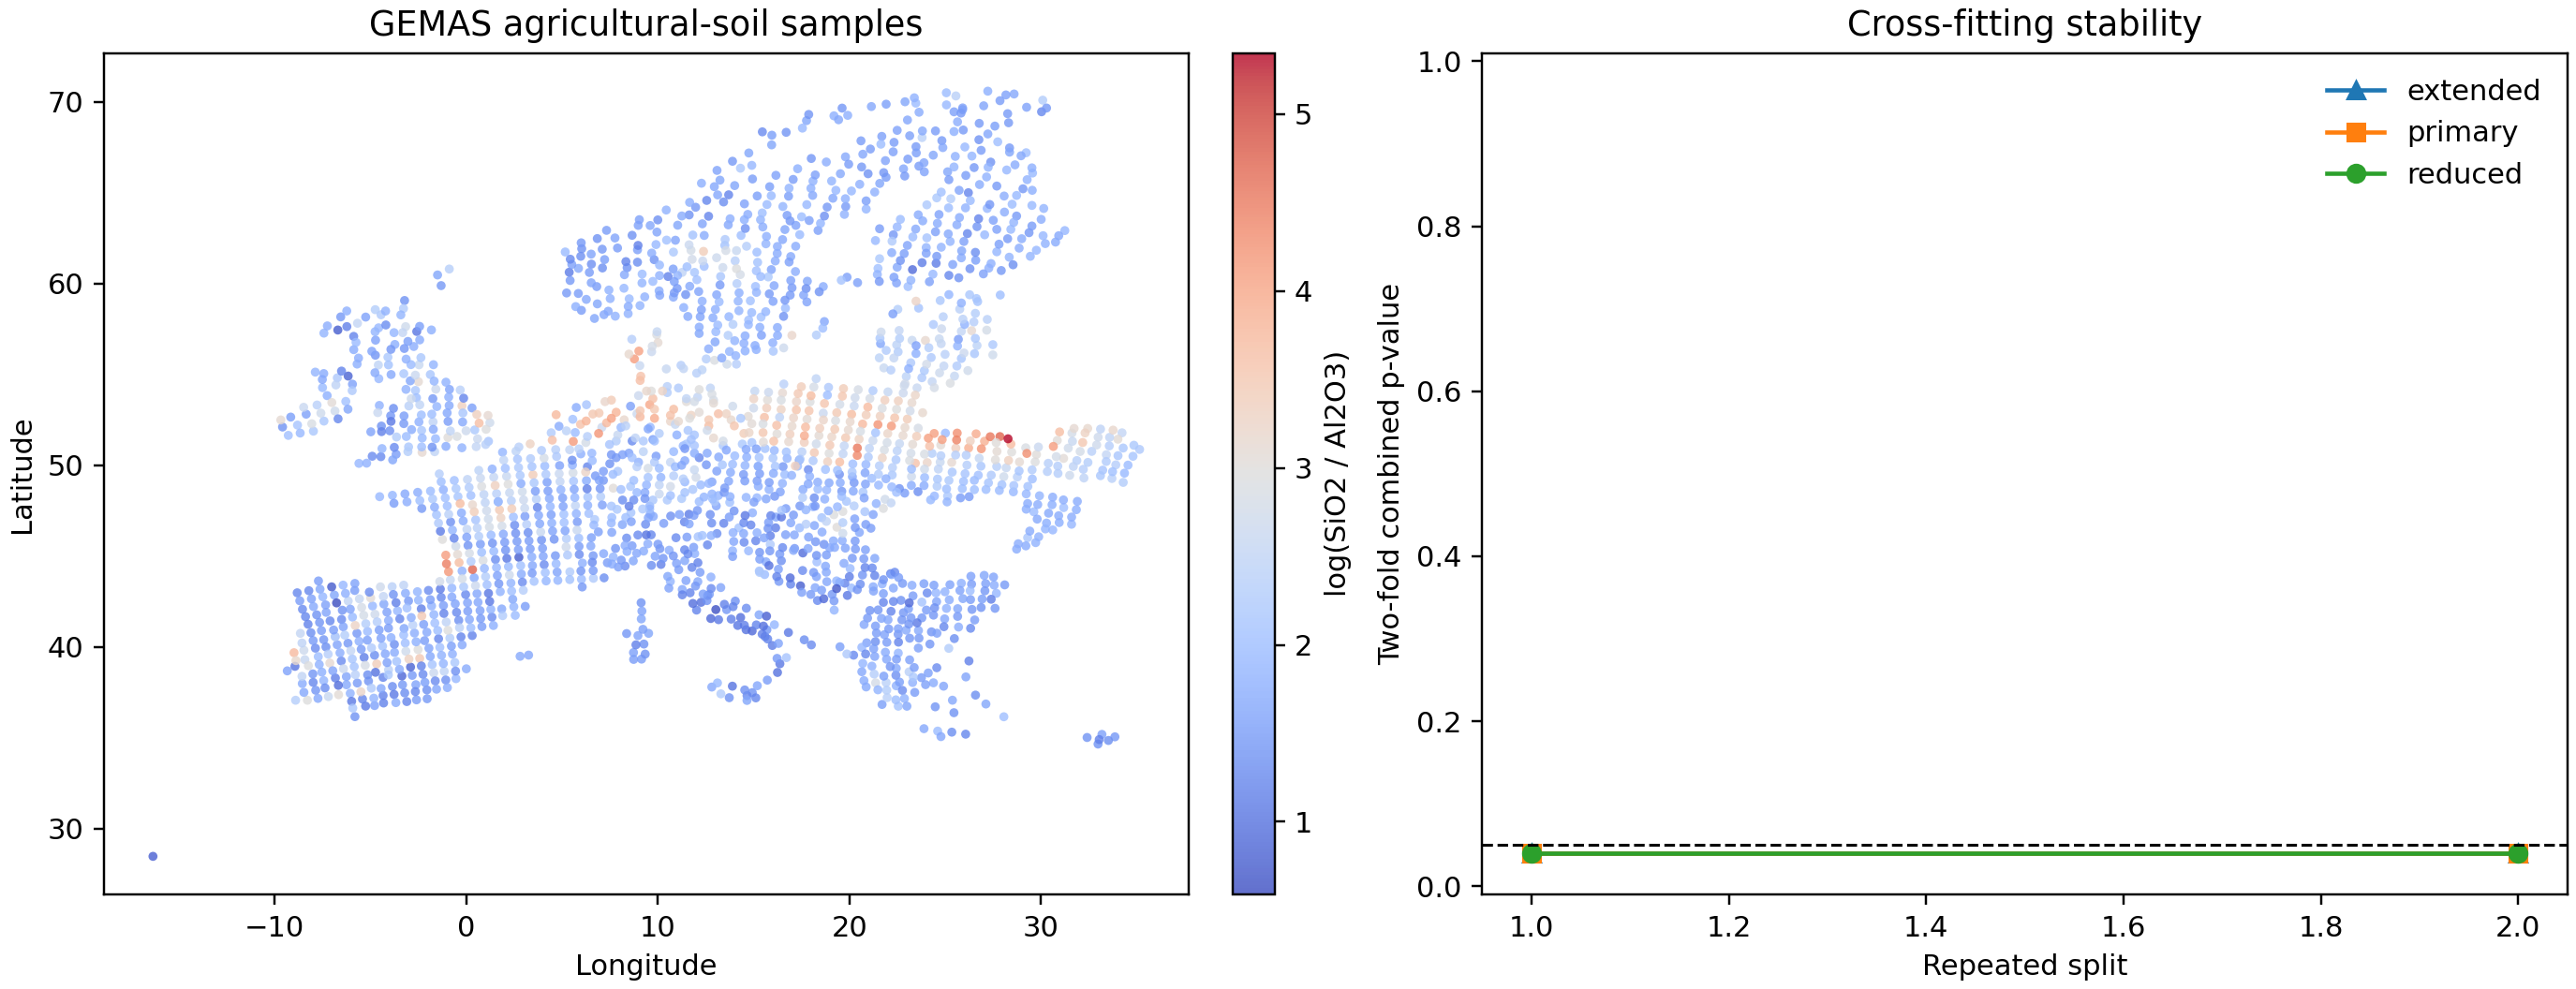

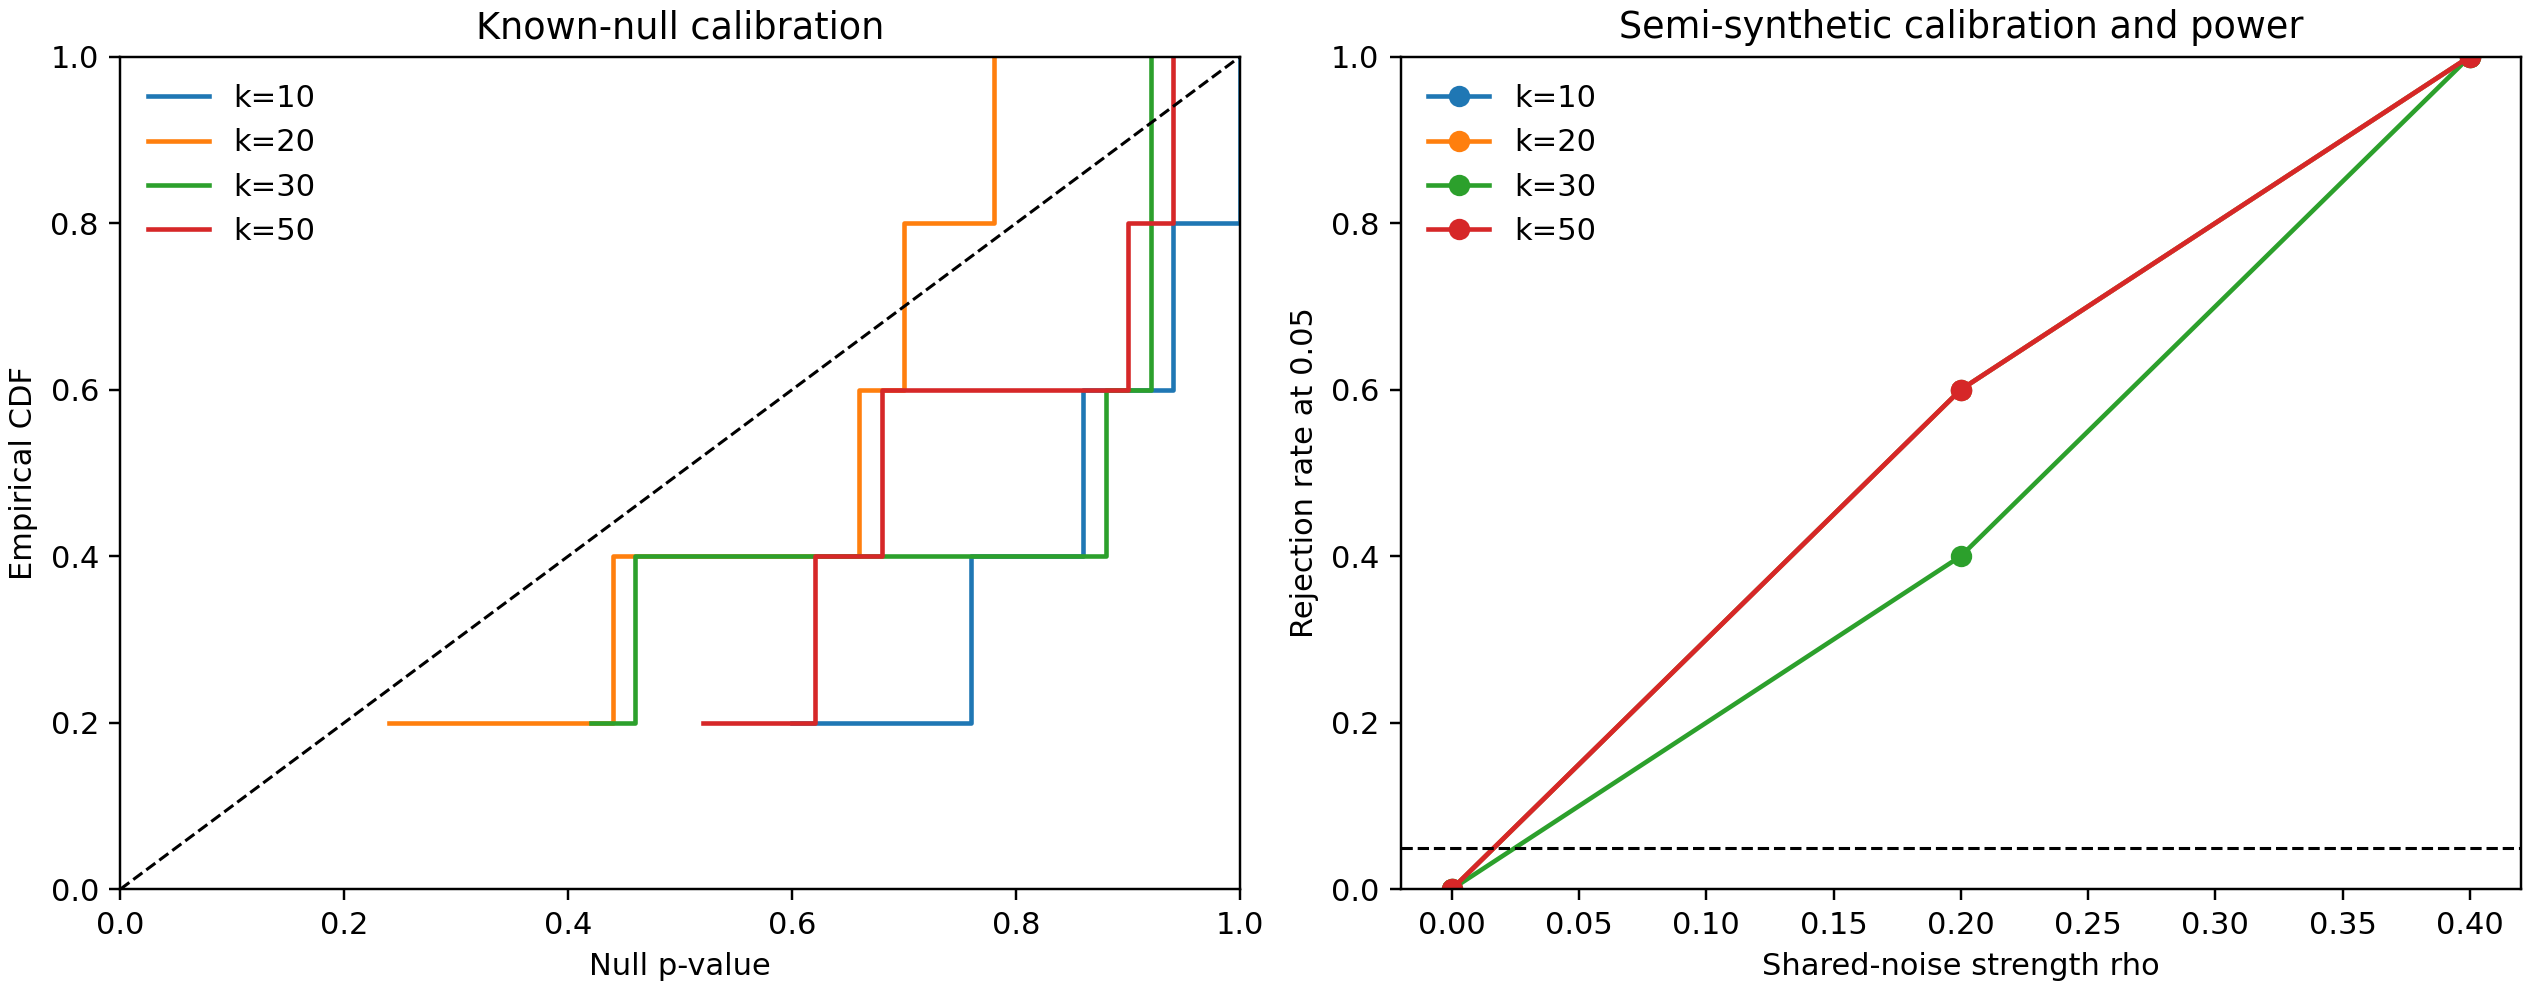

In [4]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

result_dir = Path(OUTPUT_DIR)

real_summary_path = result_dir / "real_data_summary.csv"
if real_summary_path.exists():
    print("Real-data summary")
    display(pd.read_csv(real_summary_path))

semi_summary_path = result_dir / "semisynthetic_summary.csv"
if semi_summary_path.exists():
    print("Semi-synthetic calibration and power")
    display(pd.read_csv(semi_summary_path))

main_figure = result_dir / "real_data_main_figure.png"
if main_figure.exists():
    display(Image(filename=str(main_figure)))

semi_figure = result_dir / "semisynthetic_calibration_power.png"
if semi_figure.exists():
    display(Image(filename=str(semi_figure)))


## Download the complete result archive


In [ ]:
from pathlib import Path
from google.colab import files
archive = Path(f"{OUTPUT_DIR}.zip")
if not archive.exists():
    raise FileNotFoundError(archive)
files.download(str(archive))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Suggested final runs

The complete `paper` mode can be long. It is safer to run its two components
separately after the quick results have been checked.

**Final real-data analysis:** set `MODE = "paper"`, keep
`RUN_REAL_DATA = True`, and set `RUN_SEMISYNTHETIC = False`.

**Final calibration and power experiment:** keep `MODE = "paper"`, set
`RUN_REAL_DATA = False`, and set `RUN_SEMISYNTHETIC = True`.

Use a different `OUTPUT_DIR` for each final run so that one archive does not
overwrite the other.


2.11.0+cpu
CUDA available: False
CUDA version: None


In [5]:
!python GEMAS_Sphere_CI_Colab.py \
  --mode paper \
  --skip-real \
  --device cuda \
  --semi-rhos 0.0 \
  --semi-null-reps 200 \
  --semi-k-values 10 20 30 50 \
  --output /content/gemas_sphere_null_paper

Mode: paper; torch device: cuda; output: /content/gemas_sphere_null_paper
Paper mode may require several hours. Colab GPU or a server is recommended.
Reading /content/gemas_download_cache/data/IE_GSI_GEMAS_Agricultural_Soil_Ap_Samples_AR_XRF_EU_WGS84.dbf
Analysis sample: n=2108 (removed 5 nonpositive rows)

Known-truth GEMAS-grounded semi-synthetic experiment
  rho=0.0: completed 1/200
  rho=0.0: completed 20/200
  rho=0.0: completed 40/200
  rho=0.0: completed 60/200
  rho=0.0: completed 80/200
  rho=0.0: completed 100/200
  rho=0.0: completed 120/200
  rho=0.0: completed 140/200
  rho=0.0: completed 160/200
  rho=0.0: completed 180/200
  rho=0.0: completed 200/200

Semi-synthetic summary
 rho  k_neighbors  repetitions  rejections  rejection_rate  wilson_95_lower  wilson_95_upper  median_p_value  median_statistic  median_matching_distance  median_fallback_fraction  median_outside_k_fraction  median_fixed_fraction  median_singleton_observation_fraction
 0.0           10          200   

In [6]:
!python GEMAS_Sphere_CI_Colab.py \
  --mode paper \
  --skip-real \
  --semi-rhos 0.2 0.4 \
  --semi-alt-reps 100 \
  --semi-k-values 30 \
  --output /content/gemas_sphere_power_paper

Mode: paper; torch device: cuda; output: /content/gemas_sphere_power_paper
Paper mode may require several hours. Colab GPU or a server is recommended.
Reading /content/gemas_download_cache/data/IE_GSI_GEMAS_Agricultural_Soil_Ap_Samples_AR_XRF_EU_WGS84.dbf
Analysis sample: n=2108 (removed 5 nonpositive rows)

Known-truth GEMAS-grounded semi-synthetic experiment
  rho=0.2: completed 1/100
  rho=0.2: completed 10/100
  rho=0.2: completed 20/100
  rho=0.2: completed 30/100
  rho=0.2: completed 40/100
  rho=0.2: completed 50/100
  rho=0.2: completed 60/100
  rho=0.2: completed 70/100
  rho=0.2: completed 80/100
  rho=0.2: completed 90/100
  rho=0.2: completed 100/100
  rho=0.4: completed 1/100
  rho=0.4: completed 10/100
  rho=0.4: completed 20/100
  rho=0.4: completed 30/100
  rho=0.4: completed 40/100
  rho=0.4: completed 50/100
  rho=0.4: completed 60/100
  rho=0.4: completed 70/100
  rho=0.4: completed 80/100
  rho=0.4: completed 90/100
  rho=0.4: completed 100/100
/content/GEMAS_Sphere

In [7]:
!python GEMAS_Sphere_CI_Colab.py \
  --mode paper \
  --device cuda \
  --selected-k 30 \
  --skip-semisynthetic \
  --output /content/gemas_sphere_real_paper

Mode: paper; torch device: cuda; output: /content/gemas_sphere_real_paper
Paper mode may require several hours. Colab GPU or a server is recommended.
Reading /content/gemas_download_cache/data/IE_GSI_GEMAS_Agricultural_Soil_Ap_Samples_AR_XRF_EU_WGS84.dbf
Analysis sample: n=2108 (removed 5 nonpositive rows)

Real-data analysis: reduced
  reduced, repeat 1, fold 1: T=0.00258389, p=0.0010, outside-k=0.000, fixed=0.219
  reduced, repeat 1, fold 2: T=0.00196558, p=0.0010, outside-k=0.000, fixed=0.217
  reduced, repeat 2, fold 1: T=0.00228455, p=0.0010, outside-k=0.000, fixed=0.219
  reduced, repeat 2, fold 2: T=0.0019879, p=0.0010, outside-k=0.000, fixed=0.216
  reduced, repeat 3, fold 1: T=0.00225734, p=0.0010, outside-k=0.000, fixed=0.218
  reduced, repeat 3, fold 2: T=0.00230147, p=0.0010, outside-k=0.000, fixed=0.215
  reduced, repeat 4, fold 1: T=0.00234361, p=0.0010, outside-k=0.000, fixed=0.218
  reduced, repeat 4, fold 2: T=0.00231855, p=0.0010, outside-k=0.000, fixed=0.219
  reduce

In [12]:
!python GEMAS_Sphere_CI_Colab.py \
  --mode paper \
  --device cuda \
  --analyses primary \
  --selected-k 50 \
  --skip-semisynthetic \
  --output /content/gemas_sphere_primary_k50

Mode: paper; torch device: cuda; output: /content/gemas_sphere_primary_k50
Paper mode may require several hours. Colab GPU or a server is recommended.
Reading /content/gemas_download_cache/data/IE_GSI_GEMAS_Agricultural_Soil_Ap_Samples_AR_XRF_EU_WGS84.dbf
Analysis sample: n=2108 (removed 5 nonpositive rows)

Real-data analysis: primary
  primary, repeat 1, fold 1: T=0.000862956, p=0.0010, outside-k=0.000, fixed=0.190
  primary, repeat 1, fold 2: T=0.000413644, p=0.0010, outside-k=0.000, fixed=0.185
  primary, repeat 2, fold 1: T=0.000721933, p=0.0010, outside-k=0.000, fixed=0.183
  primary, repeat 2, fold 2: T=0.000619945, p=0.0010, outside-k=0.000, fixed=0.182
  primary, repeat 3, fold 1: T=0.000716518, p=0.0010, outside-k=0.000, fixed=0.185
  primary, repeat 3, fold 2: T=0.000524139, p=0.0010, outside-k=0.000, fixed=0.182
  primary, repeat 4, fold 1: T=0.000578252, p=0.0010, outside-k=0.000, fixed=0.185
  primary, repeat 4, fold 2: T=0.000561396, p=0.0010, outside-k=0.000, fixed=0.18

In [13]:
!zip -r /content/gemas_sphere_primary_k50.zip \
  /content/gemas_sphere_primary_k50

from google.colab import files
files.download("/content/gemas_sphere_primary_k50.zip")

  adding: content/gemas_sphere_primary_k50/ (stored 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/ (stored 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary_repeat_02_fold_2.npz (deflated 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary_repeat_06_fold_1.npz (deflated 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary_repeat_04_fold_1.npz (deflated 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary_repeat_09_fold_1.npz (deflated 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary_repeat_09_fold_2.npz (deflated 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary_repeat_08_fold_2.npz (deflated 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary_repeat_10_fold_1.npz (deflated 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary_repeat_03_fold_2.npz (deflated 0%)
  adding: content/gemas_sphere_primary_k50/fold_artifacts/primary

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
%%writefile /content/GEMAS_Sphere_CI_Colab.py
#!/usr/bin/env python3
"""GEMAS sphere-valued conditional-independence analysis for Google Colab.

The script is self-contained: it downloads the official GEMAS shapefile archive,
reads the DBF table without a GIS dependency, constructs positive-sphere
compositions, runs repeated two-fold cross-fitting, and writes paper-oriented
tables and figures. It also includes a GEMAS-grounded semi-synthetic experiment
with a known conditional-independence null.

Recommended Colab workflow
---------------------------
1. Upload this file to Colab.
2. Run a small validation job:

       !python GEMAS_Sphere_CI_Colab.py --mode quick

3. Download /content/gemas_sphere_ci_output.zip and inspect it before running:

       !python GEMAS_Sphere_CI_Colab.py --mode paper

The paper mode is intentionally computationally demanding. Use
--skip-semisynthetic to run only the real-data analysis, or --analyses primary
to run only the pre-specified primary conditioning set.
"""

from __future__ import annotations

import argparse
import json
import math
import shutil
import struct
import time
import urllib.request
import warnings
import zipfile
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

try:
    import torch
except ImportError:  # The NumPy fallback keeps the script usable outside Colab.
    torch = None


if torch is None:
    def no_grad(function):
        return function
else:
    no_grad = torch.no_grad()


GEMAS_URL = (
    "https://gsi.geodata.gov.ie/downloads/Geochemistry/Data/"
    "IE_GSI_GEMAS_Geochemistry_Agricultural_Grazing_Land_Soil_EU_WGS84.zip"
)
DBF_FILENAME = "IE_GSI_GEMAS_Agricultural_Soil_Ap_Samples_AR_XRF_EU_WGS84.dbf"

OXIDE_COLUMNS = [
    "SIO2",
    "AL2O3",
    "FE2O3",
    "MGO",
    "CAO",
    "K2O",
    "NA2O",
    "TIO2",
    "P2O5",
]
X_COLUMNS = ["SIO2", "AL2O3", "FE2O3"]
Y_COLUMNS = ["CAO", "MGO", "K2O"]
W_COLUMNS = ["TIO2", "P2O5", "NA2O"]
NUMERIC_COLUMNS = ["XCOO", "YCOO", "ALT", "PH_CACL2", "TOC", "CEC"]
CATEGORICAL_COLUMNS = ["COUNTRY", "CLIMATE", "PM", "SOILCLASS", "SOILTYPE"]
DBF_COLUMNS = ["ID", *OXIDE_COLUMNS, *NUMERIC_COLUMNS, *CATEGORICAL_COLUMNS]

METHOD_SPECIFICATION = {
    "statistic": "generator-assisted MDF discrepancy",
    "integration_measure": "empirical law of generated conditionally independent copy points",
    "integration_pairs": "fixed off-diagonal ordered pairs sampled from copy points",
    "calibration": "uniform permutations within fixed mutual-k-neighbor Z-blocks",
    "block_target_size_rule": "max(3, round(sqrt(k)))",
    "generator_geometry": "ALR logistic-normal model mapped to the positive sphere",
    "generator_mean": "bootstrap ExtraTrees conditional mean",
    "generator_residuals": "OOB residual location and Ledoit-Wolf covariance with tail inflation",
}


@dataclass(frozen=True)
class AnalysisSpec:
    name: str
    use_location: bool
    numeric_names: tuple[str, ...]
    categorical_names: tuple[str, ...]


ANALYSIS_SPECS = {
    "reduced": AnalysisSpec(
        name="reduced",
        use_location=False,
        numeric_names=(),
        categorical_names=(),
    ),
    "primary": AnalysisSpec(
        name="primary",
        use_location=True,
        numeric_names=("ALT",),
        categorical_names=("CLIMATE", "PM", "SOILCLASS"),
    ),
    "extended": AnalysisSpec(
        name="extended",
        use_location=True,
        numeric_names=("ALT", "PH_CACL2", "TOC", "CEC"),
        categorical_names=("CLIMATE", "PM", "SOILCLASS"),
    ),
}


@dataclass(frozen=True)
class RunConfig:
    mode: str
    analyses: tuple[str, ...]
    random_seed: int
    real_repeats: int
    split_candidates: int
    m_profile: int
    b_permutation: int
    integration_pairs: int
    pair_batch_size: int
    k_neighbors: int
    generator_trees: int
    generator_min_leaf: int
    diagnostic_draws: int
    semi_enabled: bool
    semi_n: int
    semi_m_profile: int
    semi_b_permutation: int
    semi_integration_pairs: int
    semi_null_reps: int
    semi_alt_reps: int
    semi_rhos: tuple[float, ...]
    semi_k_values: tuple[int, ...]
    semi_rank: int
    semi_mean_strength: float
    spatial_thin_km: float = 0.0
    spatial_thin_candidates: int = 64
    k_rule: str = "fixed"


def mode_config(mode: str) -> RunConfig:
    if mode == "smoke":
        return RunConfig(
            mode=mode,
            analyses=("primary",),
            random_seed=20260906,
            real_repeats=1,
            split_candidates=8,
            m_profile=6,
            b_permutation=5,
            integration_pairs=32,
            pair_batch_size=16,
            k_neighbors=10,
            generator_trees=20,
            generator_min_leaf=12,
            diagnostic_draws=8,
            semi_enabled=True,
            semi_n=80,
            semi_m_profile=6,
            semi_b_permutation=5,
            semi_integration_pairs=24,
            semi_null_reps=1,
            semi_alt_reps=1,
            semi_rhos=(0.0, 0.4),
            semi_k_values=(10,),
            semi_rank=5,
            semi_mean_strength=0.5,
        )
    if mode == "quick":
        return RunConfig(
            mode=mode,
            analyses=("reduced", "primary", "extended"),
            random_seed=20260906,
            real_repeats=2,
            split_candidates=128,
            m_profile=30,
            b_permutation=49,
            integration_pairs=512,
            pair_batch_size=32,
            k_neighbors=30,
            generator_trees=150,
            generator_min_leaf=10,
            diagnostic_draws=50,
            semi_enabled=True,
            semi_n=1000,
            semi_m_profile=30,
            semi_b_permutation=49,
            semi_integration_pairs=384,
            semi_null_reps=5,
            semi_alt_reps=5,
            semi_rhos=(0.0, 0.2, 0.4),
            semi_k_values=(10, 20, 30, 50),
            semi_rank=5,
            semi_mean_strength=0.5,
        )
    if mode == "paper":
        return RunConfig(
            mode=mode,
            analyses=("reduced", "primary", "extended"),
            random_seed=20260906,
            real_repeats=10,
            split_candidates=512,
            m_profile=150,
            b_permutation=999,
            integration_pairs=4096,
            pair_batch_size=32,
            k_neighbors=30,
            generator_trees=400,
            generator_min_leaf=10,
            diagnostic_draws=150,
            semi_enabled=True,
            semi_n=1000,
            semi_m_profile=100,
            semi_b_permutation=199,
            semi_integration_pairs=1024,
            semi_null_reps=200,
            semi_alt_reps=100,
            semi_rhos=(0.0, 0.2, 0.4),
            semi_k_values=(10, 20, 30, 50),
            semi_rank=5,
            semi_mean_strength=0.5,
        )
    raise ValueError(f"Unknown mode: {mode}")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--mode", choices=("smoke", "quick", "paper"), default="quick")
    parser.add_argument("--dbf", type=Path, default=None, help="Use an existing GEMAS DBF file.")
    parser.add_argument(
        "--output",
        type=Path,
        default=Path("/content/gemas_sphere_ci_output"),
        help="Output directory.",
    )
    parser.add_argument(
        "--analyses",
        nargs="+",
        choices=tuple(ANALYSIS_SPECS),
        default=None,
        help="Override the conditioning sets for the real-data analysis.",
    )
    parser.add_argument("--selected-k", type=int, default=None)
    parser.add_argument(
        "--k-rule",
        choices=("fixed", "sqrt-evaluation"),
        default="fixed",
        help=(
            "Use the fixed selected k, or set k to round(sqrt(n_evaluation)) "
            "after optional spatial thinning."
        ),
    )
    parser.add_argument(
        "--spatial-thin-km",
        type=float,
        default=0.0,
        help=(
            "Minimum geographic separation in km for a reproducible spatial-"
            "thinning sensitivity analysis; zero keeps the full sample."
        ),
    )
    parser.add_argument(
        "--spatial-thin-candidates",
        type=int,
        default=64,
        help="Number of location-only greedy thinning orders to compare.",
    )
    parser.add_argument("--real-repeats", type=int, default=None)
    parser.add_argument("--semi-n", type=int, default=None)
    parser.add_argument("--semi-null-reps", type=int, default=None)
    parser.add_argument("--semi-alt-reps", type=int, default=None)
    parser.add_argument("--semi-rhos", type=float, nargs="+", default=None)
    parser.add_argument("--semi-k-values", type=int, nargs="+", default=None)
    parser.add_argument("--skip-real", action="store_true")
    parser.add_argument("--skip-semisynthetic", action="store_true")
    parser.add_argument("--seed", type=int, default=None)
    parser.add_argument(
        "--device",
        choices=("auto", "cpu", "cuda"),
        default="auto",
        help="Torch device used for the MDF statistic.",
    )
    return parser.parse_args()


def choose_device(requested: str):
    if torch is None:
        if requested == "cuda":
            raise RuntimeError("CUDA requires PyTorch, which is not installed.")
        return "cpu"
    if requested == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA was requested but is not available.")
        return torch.device("cuda")
    if requested == "cpu":
        return torch.device("cpu")
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def device_kind(device: object) -> str:
    return str(getattr(device, "type", device))


def download_gemas(output_dir: Path) -> Path:
    data_dir = output_dir / "data"
    data_dir.mkdir(parents=True, exist_ok=True)
    existing = list(data_dir.rglob(DBF_FILENAME))
    if existing:
        return existing[0]

    archive = data_dir / "gemas_agricultural_soil.zip"
    print(f"Downloading GEMAS data from {GEMAS_URL}")
    request = urllib.request.Request(
        GEMAS_URL,
        headers={"User-Agent": "Mozilla/5.0 GEMAS-research-analysis"},
    )
    with urllib.request.urlopen(request, timeout=180) as response, archive.open("wb") as handle:
        shutil.copyfileobj(response, handle)
    with zipfile.ZipFile(archive) as zipped:
        zipped.extractall(data_dir)
    matches = list(data_dir.rglob(DBF_FILENAME))
    if not matches:
        raise FileNotFoundError(f"Could not find {DBF_FILENAME} after extraction.")
    return matches[0]


def _parse_dbf_value(raw: bytes, field_type: str, encoding: str) -> object:
    text = raw.decode(encoding, errors="replace").strip()
    if not text:
        return np.nan if field_type in {"N", "F", "B", "I", "Y"} else ""
    if field_type in {"N", "F", "B", "I", "Y"}:
        try:
            return float(text)
        except ValueError:
            return np.nan
    if field_type == "L":
        return text.upper() in {"Y", "T"}
    return text


def read_dbf_columns(
    path: Path,
    selected_columns: Sequence[str],
    encoding: str = "latin-1",
) -> pd.DataFrame:
    """Read selected columns from a dBase III/IV table using the standard library."""
    selected = set(selected_columns)
    with path.open("rb") as handle:
        header = handle.read(32)
        if len(header) != 32:
            raise ValueError("The DBF header is incomplete.")
        record_count = struct.unpack("<I", header[4:8])[0]
        header_length = struct.unpack("<H", header[8:10])[0]
        record_length = struct.unpack("<H", header[10:12])[0]
        descriptors = handle.read(header_length - 32)

        fields: list[tuple[str, str, int, int]] = []
        offset = 1
        for start in range(0, len(descriptors), 32):
            descriptor = descriptors[start : start + 32]
            if not descriptor or descriptor[0] == 0x0D:
                break
            name = descriptor[:11].split(b"\x00", 1)[0].decode("ascii")
            field_type = chr(descriptor[11])
            length = int(descriptor[16])
            fields.append((name, field_type, offset, length))
            offset += length

        available = {field[0] for field in fields}
        missing = sorted(selected - available)
        if missing:
            raise KeyError(f"Missing DBF fields: {missing}")
        kept_fields = [field for field in fields if field[0] in selected]

        handle.seek(header_length)
        rows: list[dict[str, object]] = []
        for _ in range(record_count):
            record = handle.read(record_length)
            if len(record) != record_length:
                break
            if record[:1] == b"*":
                continue
            row = {
                name: _parse_dbf_value(
                    record[offset : offset + length], field_type, encoding
                )
                for name, field_type, offset, length in kept_fields
            }
            rows.append(row)
    return pd.DataFrame(rows, columns=list(selected_columns))


def numeric_frame(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    return df.loc[:, list(columns)].apply(pd.to_numeric, errors="coerce")


def to_positive_sphere(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    if values.ndim != 2 or values.shape[1] != 3:
        raise ValueError("A sphere composition must have shape (n, 3).")
    if np.any(~np.isfinite(values)) or np.any(values <= 0):
        raise ValueError("All composition entries must be finite and strictly positive.")
    proportions = values / values.sum(axis=1, keepdims=True)
    sphere = np.sqrt(proportions)
    if not np.allclose(np.linalg.norm(sphere, axis=1), 1.0, atol=1e-10):
        raise RuntimeError("The square-root composition map did not produce unit vectors.")
    return sphere


def lonlat_to_sphere(longitude: np.ndarray, latitude: np.ndarray) -> np.ndarray:
    lon = np.deg2rad(np.asarray(longitude, dtype=np.float64))
    lat = np.deg2rad(np.asarray(latitude, dtype=np.float64))
    return np.column_stack(
        [np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)]
    )


def sphere_to_alr(sphere: np.ndarray) -> np.ndarray:
    probability = np.clip(np.asarray(sphere, dtype=np.float64) ** 2, 1e-12, 1.0)
    return np.column_stack(
        [np.log(probability[:, 0] / probability[:, 2]),
         np.log(probability[:, 1] / probability[:, 2])]
    )


def alr_to_sphere(alr: np.ndarray) -> np.ndarray:
    alr = np.asarray(alr, dtype=np.float64)
    logits = np.concatenate([alr, np.zeros((*alr.shape[:-1], 1))], axis=-1)
    logits = logits - np.max(logits, axis=-1, keepdims=True)
    probability = np.exp(logits)
    probability /= probability.sum(axis=-1, keepdims=True)
    return np.sqrt(probability)


def row_geodesic(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    dots = np.sum(np.asarray(a) * np.asarray(b), axis=-1)
    return np.arccos(np.clip(dots, -1.0, 1.0))


def pairwise_geodesic(a: np.ndarray, b: np.ndarray | None = None) -> np.ndarray:
    a = np.asarray(a, dtype=np.float64)
    b = a if b is None else np.asarray(b, dtype=np.float64)
    return np.arccos(np.clip(a @ b.T, -1.0, 1.0))


def clean_and_construct(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, np.ndarray], dict[str, object]]:
    df = df_raw.copy()
    numeric_names = [*OXIDE_COLUMNS, *NUMERIC_COLUMNS]
    df[numeric_names] = numeric_frame(df, numeric_names)
    for name in CATEGORICAL_COLUMNS:
        df[name] = df[name].fillna("").astype(str).str.strip().replace("", "MISSING")

    all_positive = (df[OXIDE_COLUMNS] > 0).all(axis=1)
    finite_coordinates = np.isfinite(df["XCOO"]) & np.isfinite(df["YCOO"])
    keep = all_positive & finite_coordinates
    removed_nonpositive = int((~all_positive).sum())
    removed_coordinates = int((all_positive & ~finite_coordinates).sum())
    df = df.loc[keep].reset_index(drop=True)

    objects = {
        "X": to_positive_sphere(df[X_COLUMNS].to_numpy()),
        "Y": to_positive_sphere(df[Y_COLUMNS].to_numpy()),
        "W": to_positive_sphere(df[W_COLUMNS].to_numpy()),
        "L": lonlat_to_sphere(df["XCOO"].to_numpy(), df["YCOO"].to_numpy()),
    }
    log = {
        "raw_rows": int(len(df_raw)),
        "analysis_rows": int(len(df)),
        "removed_nonpositive_oxide_rows": removed_nonpositive,
        "removed_missing_coordinate_rows": removed_coordinates,
        "all_sphere_norms_valid": bool(
            all(np.allclose(np.linalg.norm(value, axis=1), 1.0, atol=1e-10)
                for value in objects.values())
        ),
        "all_composition_coordinates_positive": bool(
            all(np.all(objects[name] > 0) for name in ("X", "Y", "W"))
        ),
    }
    return df, objects, log


def sampled_positive_median_distance(
    values: np.ndarray,
    kind: str,
    rng: np.random.Generator,
    max_pairs: int = 20000,
) -> float:
    n = len(values)
    count = min(max_pairs, n * (n - 1) // 2)
    first = rng.integers(0, n, size=count)
    second = rng.integers(0, n - 1, size=count)
    second += second >= first
    if kind == "sphere":
        distances = row_geodesic(values[first], values[second])
    elif kind == "euclidean":
        distances = np.linalg.norm(values[first] - values[second], axis=1)
    else:
        raise ValueError(kind)
    positive = distances[np.isfinite(distances) & (distances > 0)]
    return float(np.median(positive)) if positive.size else 1.0


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float64)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, dtype=np.float64)


@dataclass
class ZEncoder:
    spec: AnalysisSpec
    numeric_medians: np.ndarray | None = None
    numeric_scaler: StandardScaler | None = None
    category_encoder: OneHotEncoder | None = None

    def fit(self, df: pd.DataFrame, objects: dict[str, np.ndarray], indices: np.ndarray) -> "ZEncoder":
        if self.spec.numeric_names:
            numeric = numeric_frame(df, self.spec.numeric_names).to_numpy(dtype=np.float64)
            self.numeric_medians = np.nanmedian(numeric[indices], axis=0)
            train = numeric[indices].copy()
            missing = ~np.isfinite(train)
            train[missing] = np.take(self.numeric_medians, np.where(missing)[1])
            self.numeric_scaler = StandardScaler().fit(train)
        if self.spec.categorical_names:
            self.category_encoder = make_one_hot_encoder()
            self.category_encoder.fit(df.loc[indices, list(self.spec.categorical_names)].astype(str))
        return self

    def transform(self, df: pd.DataFrame, objects: dict[str, np.ndarray], indices: np.ndarray) -> np.ndarray:
        blocks = [sphere_to_alr(objects["W"][indices])]
        if self.spec.use_location:
            blocks.append(objects["L"][indices])
        if self.spec.numeric_names:
            if self.numeric_medians is None or self.numeric_scaler is None:
                raise RuntimeError("ZEncoder has not been fitted.")
            numeric = numeric_frame(df.iloc[indices], self.spec.numeric_names).to_numpy(dtype=np.float64)
            missing = ~np.isfinite(numeric)
            numeric[missing] = np.take(self.numeric_medians, np.where(missing)[1])
            blocks.append(self.numeric_scaler.transform(numeric))
        if self.spec.categorical_names:
            if self.category_encoder is None:
                raise RuntimeError("ZEncoder has not been fitted.")
            blocks.append(
                self.category_encoder.transform(
                    df.loc[indices, list(self.spec.categorical_names)].astype(str)
                )
            )
        return np.concatenate(blocks, axis=1).astype(np.float64)


@dataclass
class ProductMetric:
    spec: AnalysisSpec
    w_scale: float = 1.0
    location_scale: float = 1.0
    numeric_medians: np.ndarray | None = None
    numeric_scaler: StandardScaler | None = None
    numeric_distance_scale: float = 1.0

    def fit(
        self,
        df: pd.DataFrame,
        objects: dict[str, np.ndarray],
        indices: np.ndarray,
        rng: np.random.Generator,
    ) -> "ProductMetric":
        self.w_scale = sampled_positive_median_distance(
            objects["W"][indices], "sphere", rng
        )
        if self.spec.use_location:
            self.location_scale = sampled_positive_median_distance(
                objects["L"][indices], "sphere", rng
            )
        if self.spec.numeric_names:
            numeric = numeric_frame(df, self.spec.numeric_names).to_numpy(dtype=np.float64)
            self.numeric_medians = np.nanmedian(numeric[indices], axis=0)
            train = numeric[indices].copy()
            missing = ~np.isfinite(train)
            train[missing] = np.take(self.numeric_medians, np.where(missing)[1])
            self.numeric_scaler = StandardScaler().fit(train)
            standardized = self.numeric_scaler.transform(train)
            self.numeric_distance_scale = sampled_positive_median_distance(
                standardized, "euclidean", rng
            )
        return self

    def distance(
        self,
        df: pd.DataFrame,
        objects: dict[str, np.ndarray],
        indices: np.ndarray,
    ) -> np.ndarray:
        blocks = [pairwise_geodesic(objects["W"][indices]) / self.w_scale]
        if self.spec.use_location:
            blocks.append(
                pairwise_geodesic(objects["L"][indices]) / self.location_scale
            )
        if self.spec.numeric_names:
            if self.numeric_medians is None or self.numeric_scaler is None:
                raise RuntimeError("ProductMetric has not been fitted.")
            numeric = numeric_frame(df.iloc[indices], self.spec.numeric_names).to_numpy(dtype=np.float64)
            missing = ~np.isfinite(numeric)
            numeric[missing] = np.take(self.numeric_medians, np.where(missing)[1])
            standardized = self.numeric_scaler.transform(numeric)
            blocks.append(cdist(standardized, standardized) / self.numeric_distance_scale)
        if self.spec.categorical_names:
            categories = df.loc[indices, list(self.spec.categorical_names)].astype(str).to_numpy()
            mismatch = np.zeros((len(indices), len(indices)), dtype=np.float64)
            for column in range(categories.shape[1]):
                mismatch += categories[:, column, None] != categories[None, :, column]
            blocks.append(np.sqrt(mismatch / categories.shape[1]))
        squared = np.zeros_like(blocks[0])
        for block in blocks:
            squared += block * block
        distance = np.sqrt(squared / len(blocks))
        np.fill_diagonal(distance, 0.0)
        return distance

    def diagnostics(self) -> dict[str, float]:
        return {
            "metric_w_scale": float(self.w_scale),
            "metric_location_scale": float(self.location_scale),
            "metric_numeric_scale": float(self.numeric_distance_scale),
        }


class ConditionalCompositionGenerator:
    """Nonlinear conditional mean with OOB-calibrated logistic-normal residuals."""

    def __init__(self, n_trees: int, min_leaf: int, seed: int) -> None:
        self.model = ExtraTreesRegressor(
            n_estimators=n_trees,
            min_samples_leaf=min_leaf,
            max_features=1.0,
            bootstrap=True,
            max_samples=0.8,
            oob_score=True,
            n_jobs=-1,
            random_state=seed,
        )
        self.residual_covariance: np.ndarray | None = None
        self.residual_cholesky: np.ndarray | None = None
        self.residual_location = np.zeros(2, dtype=np.float64)
        self.residual_scale_inflation = 1.0
        self.oob_residual_rows = 0

    def fit(self, z: np.ndarray, sphere: np.ndarray) -> "ConditionalCompositionGenerator":
        target = sphere_to_alr(sphere)
        self.model.fit(z, target)
        oob_prediction = np.asarray(self.model.oob_prediction_, dtype=np.float64)
        valid = np.all(np.isfinite(oob_prediction), axis=1)
        if int(np.sum(valid)) < max(50, target.shape[1] + 2):
            raise RuntimeError("Too few valid OOB predictions to calibrate the generator.")
        residual = target[valid] - oob_prediction[valid]
        self.oob_residual_rows = int(len(residual))
        self.residual_location = np.mean(residual, axis=0)
        centered = residual - self.residual_location
        covariance = LedoitWolf().fit(centered).covariance_
        marginal_sd = np.sqrt(np.maximum(np.diag(covariance), 1e-12))
        standardized_abs = np.abs(centered) / marginal_sd
        empirical_abs_90 = np.quantile(standardized_abs, 0.90, axis=0)
        gaussian_abs_90 = 1.6448536269514722
        self.residual_scale_inflation = float(
            np.clip(np.max(empirical_abs_90 / gaussian_abs_90), 1.0, 2.0)
        )
        covariance *= self.residual_scale_inflation**2
        covariance = covariance + 1e-8 * np.eye(covariance.shape[0])
        self.residual_covariance = covariance
        self.residual_cholesky = np.linalg.cholesky(covariance)
        return self

    def mean_alr(self, z: np.ndarray) -> np.ndarray:
        prediction = np.asarray(self.model.predict(z), dtype=np.float64)
        return prediction + self.residual_location

    def from_noise(self, z: np.ndarray, noise: np.ndarray) -> np.ndarray:
        if self.residual_cholesky is None:
            raise RuntimeError("The generator must be fitted before sampling.")
        mean = self.mean_alr(z)
        transformed = np.asarray(noise, dtype=np.float64) @ self.residual_cholesky.T
        if transformed.ndim == 2:
            generated = mean + transformed
        elif transformed.ndim == 3:
            generated = mean[:, None, :] + transformed
        else:
            raise ValueError("Noise must have shape (n, 2) or (n, draws, 2).")
        return alr_to_sphere(generated)

    def sample(
        self,
        z: np.ndarray,
        draws: int,
        rng: np.random.Generator,
    ) -> np.ndarray:
        noise = rng.standard_normal((len(z), draws, 2))
        return self.from_noise(z, noise)


class SmoothLowRankCompositionGenerator:
    """Smooth rank-five quadratic logistic-normal model for known-truth experiments."""

    def __init__(self, rank: int, mean_strength: float, seed: int) -> None:
        self.rank = rank
        self.mean_strength = mean_strength
        self.seed = seed
        self.z_scaler = StandardScaler()
        self.pca: PCA | None = None
        self.basis = PolynomialFeatures(degree=2, include_bias=False)
        self.target_scaler = StandardScaler()
        self.regression = RidgeCV(alphas=np.logspace(-3, 3, 19))
        self.residual_cholesky: np.ndarray | None = None

    def _features(self, z: np.ndarray, fit: bool = False) -> np.ndarray:
        if fit:
            standardized = self.z_scaler.fit_transform(z)
            components = min(self.rank, standardized.shape[1], len(standardized) - 1)
            self.pca = PCA(n_components=components, random_state=self.seed).fit(standardized)
            scores = self.pca.transform(standardized)
            return self.basis.fit_transform(scores)
        if self.pca is None:
            raise RuntimeError("The smooth generator has not been fitted.")
        scores = self.pca.transform(self.z_scaler.transform(z))
        return self.basis.transform(scores)

    def fit(self, z: np.ndarray, sphere: np.ndarray) -> "SmoothLowRankCompositionGenerator":
        features = self._features(z, fit=True)
        target = sphere_to_alr(sphere)
        target_scaled = self.target_scaler.fit_transform(target)
        self.regression.fit(features, target_scaled)
        residual = target_scaled - self.mean_strength * self.regression.predict(features)
        covariance = LedoitWolf().fit(residual).covariance_ + 1e-8 * np.eye(2)
        self.residual_cholesky = np.linalg.cholesky(covariance)
        return self

    def mean_alr(self, z: np.ndarray) -> np.ndarray:
        prediction = self.mean_strength * self.regression.predict(self._features(z))
        return self.target_scaler.inverse_transform(prediction)

    def from_noise(self, z: np.ndarray, noise: np.ndarray) -> np.ndarray:
        if self.residual_cholesky is None:
            raise RuntimeError("The smooth generator must be fitted before sampling.")
        features = self._features(z)
        mean_scaled = self.mean_strength * self.regression.predict(features)
        transformed = np.asarray(noise, dtype=np.float64) @ self.residual_cholesky.T
        if transformed.ndim == 2:
            generated_scaled = mean_scaled + transformed
            generated = self.target_scaler.inverse_transform(generated_scaled)
        elif transformed.ndim == 3:
            generated_scaled = mean_scaled[:, None, :] + transformed
            flat = self.target_scaler.inverse_transform(
                generated_scaled.reshape(-1, generated_scaled.shape[-1])
            )
            generated = flat.reshape(generated_scaled.shape)
        else:
            raise ValueError("Noise must have shape (n, 2) or (n, draws, 2).")
        return alr_to_sphere(generated)

    def sample(
        self,
        z: np.ndarray,
        draws: int,
        rng: np.random.Generator,
    ) -> np.ndarray:
        return self.from_noise(z, rng.standard_normal((len(z), draws, 2)))


def generator_diagnostics(
    generator: ConditionalCompositionGenerator,
    z: np.ndarray,
    observed: np.ndarray,
    draws: int,
    rng: np.random.Generator,
) -> dict[str, float]:
    truth_alr = sphere_to_alr(observed)
    prediction_alr = generator.mean_alr(z)
    generated_a = generator.sample(z, draws, rng)
    generated_b = generator.sample(z, draws, rng)
    distance_to_truth = np.arccos(
        np.clip(np.sum(generated_a * observed[:, None, :], axis=2), -1.0, 1.0)
    )
    paired_distance = np.arccos(
        np.clip(np.sum(generated_a * generated_b, axis=2), -1.0, 1.0)
    )
    energy_score = float(np.mean(distance_to_truth) - 0.5 * np.mean(paired_distance))
    lower = np.quantile(generated_a, 0.05, axis=1)
    upper = np.quantile(generated_a, 0.95, axis=1)
    covered = (observed >= lower) & (observed <= upper)
    norm_error = np.max(np.abs(np.linalg.norm(generated_a, axis=2) - 1.0))
    return {
        "alr_multivariate_r2": float(
            r2_score(truth_alr, prediction_alr, multioutput="variance_weighted")
        ),
        "alr_rmse": float(np.sqrt(np.mean((truth_alr - prediction_alr) ** 2))),
        "sphere_energy_score": energy_score,
        "component_90pct_coverage": float(np.mean(covered)),
        "generated_positive_fraction": float(np.mean(generated_a > 0)),
        "generated_max_norm_error": float(norm_error),
        "oob_residual_rows": float(generator.oob_residual_rows),
        "residual_scale_inflation": float(generator.residual_scale_inflation),
    }


def build_balance_features(df: pd.DataFrame, objects: dict[str, np.ndarray]) -> np.ndarray:
    numeric_names = ["ALT", "PH_CACL2", "TOC", "CEC"]
    numeric = numeric_frame(df, numeric_names).to_numpy(dtype=np.float64)
    medians = np.nanmedian(numeric, axis=0)
    missing = ~np.isfinite(numeric)
    numeric[missing] = np.take(medians, np.where(missing)[1])
    numeric = StandardScaler().fit_transform(numeric)
    categories = pd.get_dummies(
        df[["COUNTRY", "CLIMATE", "PM", "SOILCLASS"]].astype(str),
        dtype=float,
    ).to_numpy(dtype=np.float64)
    continuous = np.concatenate(
        [numeric, sphere_to_alr(objects["W"]), objects["L"]], axis=1
    )
    continuous = StandardScaler().fit_transform(continuous)
    return np.concatenate([continuous, categories], axis=1)


def balanced_two_folds(
    n: int,
    balance_features: np.ndarray,
    candidates: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, dict[str, float]]:
    splitter = ShuffleSplit(
        n_splits=candidates,
        test_size=0.5,
        random_state=seed,
    )
    best: tuple[float, float, np.ndarray, np.ndarray] | None = None
    for first, second in splitter.split(balance_features):
        difference = np.abs(
            balance_features[first].mean(axis=0)
            - balance_features[second].mean(axis=0)
        )
        rms = float(np.sqrt(np.mean(difference * difference)))
        maximum = float(np.max(difference))
        if best is None or (rms, maximum) < (best[0], best[1]):
            best = (rms, maximum, first.copy(), second.copy())
    if best is None:
        raise RuntimeError("No candidate split was generated.")
    if len(best[2]) != n // 2 or len(best[3]) != n - n // 2:
        raise RuntimeError("The selected split is not a two-fold partition.")
    return best[2], best[3], {
        "balance_rms_mean_difference": best[0],
        "balance_max_mean_difference": best[1],
    }


def spatial_morans_i(
    values: np.ndarray,
    location: np.ndarray,
    k: int = 10,
) -> float:
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    centered = values - np.mean(values)
    denominator = float(np.sum(centered * centered))
    if denominator <= 0 or len(values) <= k:
        return float("nan")
    distance = pairwise_geodesic(location)
    np.fill_diagonal(distance, np.inf)
    neighbors = np.argsort(distance, axis=1)[:, :k]
    numerator = float(np.sum(centered[:, None] * centered[neighbors]))
    weight_sum = len(values) * k
    return float(len(values) * numerator / (weight_sum * denominator))


def spatially_thin_locations(
    location: np.ndarray,
    minimum_distance_km: float,
    candidates: int,
    seed: int,
) -> tuple[np.ndarray, dict[str, float | int]]:
    """Select a large location-only subset with the requested separation."""
    if minimum_distance_km <= 0:
        indices = np.arange(len(location), dtype=np.int64)
        return indices, {
            "spatial_thin_km": 0.0,
            "spatial_thin_candidates": 0,
            "pre_thinning_n": int(len(indices)),
            "post_thinning_n": int(len(indices)),
            "achieved_minimum_distance_km": 0.0,
        }
    if candidates < 1:
        raise ValueError("spatial-thin-candidates must be positive.")

    earth_radius_km = 6371.0088
    distance_km = pairwise_geodesic(location) * earth_radius_km
    rng = np.random.default_rng(seed)
    best = np.empty(0, dtype=np.int64)
    for _ in range(candidates):
        available = np.ones(len(location), dtype=bool)
        selected: list[int] = []
        for index in rng.permutation(len(location)):
            if not available[index]:
                continue
            selected.append(int(index))
            available[distance_km[index] < minimum_distance_km] = False
        candidate = np.sort(np.asarray(selected, dtype=np.int64))
        if len(candidate) > len(best):
            best = candidate

    if len(best) < 4:
        raise RuntimeError(
            "Spatial thinning retained fewer than four observations; reduce "
            "spatial-thin-km."
        )
    retained_distance = distance_km[np.ix_(best, best)]
    upper = retained_distance[np.triu_indices(len(best), k=1)]
    achieved = float(np.min(upper)) if len(upper) else float("nan")
    return best, {
        "spatial_thin_km": float(minimum_distance_km),
        "spatial_thin_candidates": int(candidates),
        "pre_thinning_n": int(len(location)),
        "post_thinning_n": int(len(best)),
        "achieved_minimum_distance_km": achieved,
    }


def sample_ordered_pairs(
    n: int,
    count: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    total = n * (n - 1)
    count = min(count, total)
    encoded = rng.choice(total, size=count, replace=False)
    first = encoded // (n - 1)
    remainder = encoded % (n - 1)
    second = remainder + (remainder >= first)
    return first.astype(np.int64), second.astype(np.int64)


def torch_row_geodesic(a, b):
    return torch.acos(torch.clamp(torch.sum(a * b, dim=-1), -1.0, 1.0))


@no_grad
def prepare_statistic_cache(
    x_observed: np.ndarray,
    y_observed: np.ndarray,
    z_distance: np.ndarray,
    x_generated: np.ndarray,
    y_generated: np.ndarray,
    pair_count: int,
    pair_batch_size: int,
    pair_seed: int,
    device: object,
) -> dict[str, object]:
    """Build fixed independent-copy integration balls and reusable MDF arrays."""
    n = len(x_observed)
    if x_generated.shape[1] < 2 or y_generated.shape[1] < 2:
        raise ValueError("At least one copy draw and one profile draw are required.")
    rng = np.random.default_rng(pair_seed)
    first_np, second_np = sample_ordered_pairs(n, pair_count, rng)
    q = len(first_np)
    m = x_generated.shape[1] - 1
    if torch is None:
        x_obs = np.asarray(x_observed, dtype=np.float32)
        y_obs = np.asarray(y_observed, dtype=np.float32)
        x_copy = np.asarray(x_generated[:, 0], dtype=np.float32)
        y_copy = np.asarray(y_generated[:, 0], dtype=np.float32)
        x_profile = np.asarray(x_generated[:, 1:], dtype=np.float32)
        y_profile = np.asarray(y_generated[:, 1:], dtype=np.float32)
        xz_membership = np.empty((q, n), dtype=np.float32)
        y_membership = np.empty((q, n), dtype=bool)
        factorized_mdf = np.empty(q, dtype=np.float32)
        z_distance = np.asarray(z_distance, dtype=np.float32)
        for start in range(0, q, pair_batch_size):
            stop = min(start + pair_batch_size, q)
            a_np = first_np[start:stop]
            b_np = second_np[start:stop]
            center_x = x_copy[a_np]
            center_y = y_copy[a_np]
            radius_x = row_geodesic(center_x, x_copy[b_np])
            radius_y = row_geodesic(center_y, y_copy[b_np])
            distance_x_obs = np.arccos(np.clip(center_x @ x_obs.T, -1.0, 1.0))
            distance_y_obs = np.arccos(np.clip(center_y @ y_obs.T, -1.0, 1.0))
            distance_x_profile = np.arccos(
                np.clip(np.einsum("qd,nmd->qnm", center_x, x_profile), -1.0, 1.0)
            )
            distance_y_profile = np.arccos(
                np.clip(np.einsum("qd,nmd->qnm", center_y, y_profile), -1.0, 1.0)
            )
            in_x = distance_x_obs <= radius_x[:, None]
            in_y = distance_y_obs <= radius_y[:, None]
            profile_x = np.mean(
                distance_x_profile <= radius_x[:, None, None], axis=2
            )
            profile_y = np.mean(
                distance_y_profile <= radius_y[:, None, None], axis=2
            )
            in_z = z_distance[a_np] <= z_distance[a_np, b_np, None]
            xz_membership[start:stop] = (in_x & in_z).astype(np.float32)
            y_membership[start:stop] = in_y
            factorized_mdf[start:stop] = np.mean(
                profile_x * profile_y * in_z, axis=1
            )
        return {
            "xz_membership": xz_membership,
            "y_membership": y_membership,
            "factorized_mdf": factorized_mdf,
            "first": first_np,
            "second": second_np,
            "n": n,
            "m": m,
            "pair_count": q,
        }

    dtype = torch.float32

    x_obs = torch.as_tensor(x_observed, dtype=dtype, device=device)
    y_obs = torch.as_tensor(y_observed, dtype=dtype, device=device)
    x_copy = torch.as_tensor(x_generated[:, 0], dtype=dtype, device=device)
    y_copy = torch.as_tensor(y_generated[:, 0], dtype=dtype, device=device)
    x_profile = torch.as_tensor(x_generated[:, 1:], dtype=dtype, device=device)
    y_profile = torch.as_tensor(y_generated[:, 1:], dtype=dtype, device=device)
    first = torch.as_tensor(first_np, dtype=torch.long, device=device)
    second = torch.as_tensor(second_np, dtype=torch.long, device=device)

    xz_membership = torch.empty((q, n), dtype=dtype, device=device)
    y_membership = torch.empty((q, n), dtype=torch.bool, device=device)
    factorized_mdf = torch.empty(q, dtype=dtype, device=device)

    z_distance = np.asarray(z_distance, dtype=np.float32)
    for start in range(0, q, pair_batch_size):
        stop = min(start + pair_batch_size, q)
        a = first[start:stop]
        b = second[start:stop]
        a_np = first_np[start:stop]
        b_np = second_np[start:stop]

        center_x = x_copy[a]
        center_y = y_copy[a]
        radius_x = torch_row_geodesic(center_x, x_copy[b])
        radius_y = torch_row_geodesic(center_y, y_copy[b])

        distance_x_obs = torch.acos(
            torch.clamp(center_x @ x_obs.T, -1.0, 1.0)
        )
        distance_y_obs = torch.acos(
            torch.clamp(center_y @ y_obs.T, -1.0, 1.0)
        )
        distance_x_profile = torch.acos(
            torch.clamp(torch.einsum("qd,nmd->qnm", center_x, x_profile), -1.0, 1.0)
        )
        distance_y_profile = torch.acos(
            torch.clamp(torch.einsum("qd,nmd->qnm", center_y, y_profile), -1.0, 1.0)
        )
        in_x = distance_x_obs <= radius_x[:, None]
        in_y = distance_y_obs <= radius_y[:, None]
        profile_x = (distance_x_profile <= radius_x[:, None, None]).float().mean(dim=2)
        profile_y = (distance_y_profile <= radius_y[:, None, None]).float().mean(dim=2)
        in_z_np = z_distance[a_np] <= z_distance[a_np, b_np, None]
        in_z = torch.as_tensor(in_z_np, dtype=torch.bool, device=device)

        xz_membership[start:stop] = (in_x & in_z).float()
        y_membership[start:stop] = in_y
        factorized_mdf[start:stop] = (
            profile_x * profile_y * in_z.float()
        ).mean(dim=1)

    return {
        "xz_membership": xz_membership,
        "y_membership": y_membership,
        "factorized_mdf": factorized_mdf,
        "first": first_np,
        "second": second_np,
        "n": n,
        "m": m,
        "pair_count": q,
    }


@no_grad
def cached_statistic(cache: dict[str, object], assignment: np.ndarray | None = None) -> float:
    xz = cache["xz_membership"]
    y = cache["y_membership"]
    factorized = cache["factorized_mdf"]
    if torch is None:
        xz_array = np.asarray(xz)
        y_array = np.asarray(y)
        factorized_array = np.asarray(factorized)
        if assignment is not None:
            y_array = y_array[:, assignment]
        joint = np.mean(xz_array * y_array, axis=1)
        return float(np.mean((joint - factorized_array) ** 2))
    if not isinstance(xz, torch.Tensor) or not isinstance(y, torch.Tensor):
        raise TypeError("Invalid statistic cache.")
    if not isinstance(factorized, torch.Tensor):
        raise TypeError("Invalid statistic cache.")
    if assignment is not None:
        columns = torch.as_tensor(assignment, dtype=torch.long, device=xz.device)
        y = y.index_select(1, columns)
    joint = (xz * y.float()).mean(dim=1)
    return float(torch.mean((joint - factorized) ** 2).cpu())


def neighbor_order(z_distance: np.ndarray, k: int) -> np.ndarray:
    if not 1 <= k < len(z_distance):
        raise ValueError(f"k={k} is invalid for n={len(z_distance)}.")
    distance = np.asarray(z_distance, dtype=np.float64).copy()
    np.fill_diagonal(distance, np.inf)
    return np.argsort(distance, axis=1)[:, : len(distance) - 1]


def build_local_blocks(
    z_distance: np.ndarray,
    ordered_neighbors: np.ndarray,
    k: int,
    block_size: int,
) -> list[np.ndarray]:
    """Partition Z into compact cliques of the mutual k-neighbor graph."""
    n = len(z_distance)
    block_size = max(2, min(int(block_size), n))
    distance = np.asarray(z_distance, dtype=np.float64).copy()
    np.fill_diagonal(distance, np.inf)
    directed = np.zeros((n, n), dtype=bool)
    directed[np.arange(n)[:, None], ordered_neighbors[:, :k]] = True
    mutual = directed & directed.T
    np.fill_diagonal(mutual, True)
    mutual_degree = np.sum(mutual, axis=1) - 1
    nearest_distance = np.min(distance, axis=1)
    seed_order = np.lexsort((-nearest_distance, mutual_degree))
    available = np.ones(n, dtype=bool)
    blocks: list[np.ndarray] = []
    pointer = 0
    while np.any(available):
        while not available[seed_order[pointer]]:
            pointer += 1
        seed = int(seed_order[pointer])
        block_list = [seed]
        candidates = np.flatnonzero(available & mutual[seed])
        candidates = candidates[candidates != seed]
        while len(block_list) < block_size and len(candidates):
            compatible = np.all(mutual[np.ix_(candidates, block_list)], axis=1)
            candidates = candidates[compatible]
            if not len(candidates):
                break
            complete_link_distance = np.max(
                distance[np.ix_(np.asarray(block_list), candidates)], axis=0
            )
            selected_position = int(np.argmin(complete_link_distance))
            block_list.append(int(candidates[selected_position]))
            candidates = np.delete(candidates, selected_position)
        block = np.asarray(block_list, dtype=np.int64)
        available[block] = False
        blocks.append(block)

    combined = np.concatenate(blocks)
    if len(combined) != n or np.unique(combined).size != n:
        raise RuntimeError("The local blocks do not partition the observations.")
    for block in blocks:
        if not np.all(mutual[np.ix_(block, block)]):
            raise RuntimeError("A local block is not a mutual-k-neighbor clique.")
    return blocks


def local_block_permutation(
    blocks: Sequence[np.ndarray],
    n: int,
    rng: np.random.Generator,
) -> np.ndarray:
    assignment = np.arange(n, dtype=np.int64)
    for block in blocks:
        assignment[block] = rng.permutation(block)
    if np.unique(assignment).size != n:
        raise RuntimeError("The blockwise local permutation is not a bijection.")
    return assignment


def local_permutation_test(
    cache: dict[str, object],
    z_distance: np.ndarray,
    k: int,
    b_permutation: int,
    seed: int,
) -> dict[str, object]:
    rng = np.random.default_rng(seed)
    ordered_neighbors = neighbor_order(z_distance, k)
    block_size = max(3, int(round(math.sqrt(k))))
    blocks = build_local_blocks(
        z_distance,
        ordered_neighbors=ordered_neighbors,
        k=k,
        block_size=block_size,
    )
    allowed_matrix = np.zeros((len(z_distance), len(z_distance)), dtype=bool)
    allowed_matrix[np.arange(len(z_distance))[:, None], ordered_neighbors[:, :k]] = True
    np.fill_diagonal(allowed_matrix, True)
    observed = cached_statistic(cache)
    permuted = np.empty(b_permutation, dtype=np.float64)
    outside_k = np.empty(b_permutation, dtype=np.float64)
    fixed = np.empty(b_permutation, dtype=np.float64)
    matched_mean = np.empty(b_permutation, dtype=np.float64)
    matched_p90 = np.empty(b_permutation, dtype=np.float64)
    for b in range(b_permutation):
        assignment = local_block_permutation(blocks, len(z_distance), rng)
        permuted[b] = cached_statistic(cache, assignment)
        matched = z_distance[np.arange(len(assignment)), assignment]
        allowed = allowed_matrix[np.arange(len(assignment)), assignment]
        outside_k[b] = float(np.mean(~allowed))
        fixed[b] = float(np.mean(assignment == np.arange(len(assignment))))
        matched_mean[b] = float(np.mean(matched))
        matched_p90[b] = float(np.quantile(matched, 0.9))
    p_value = float((1 + np.sum(permuted >= observed - 1e-14)) / (b_permutation + 1))
    positive = z_distance[np.triu_indices_from(z_distance, k=1)]
    positive = positive[positive > 0]
    global_scale = float(np.median(positive)) if positive.size else 1.0
    return {
        "statistic": observed,
        "p_value": p_value,
        "permutation_mean": float(np.mean(permuted)),
        "permutation_sd": float(np.std(permuted, ddof=1)) if b_permutation > 1 else 0.0,
        "matching_outside_k_fraction": float(np.mean(outside_k)),
        "matching_fallback_fraction": float(np.mean(outside_k)),
        "matching_fixed_fraction": float(np.mean(fixed)),
        "matching_mean_distance": float(np.mean(matched_mean)),
        "matching_p90_distance": float(np.mean(matched_p90)),
        "matching_mean_over_global_median": float(np.mean(matched_mean) / global_scale),
        "local_block_count": int(len(blocks)),
        "local_block_min_size": int(min(map(len, blocks))),
        "local_block_median_size": float(np.median(list(map(len, blocks)))),
        "local_block_max_size": int(max(map(len, blocks))),
        "local_singleton_observation_fraction": float(
            np.sum([len(block) for block in blocks if len(block) == 1]) / len(z_distance)
        ),
        "permuted_statistics": permuted,
    }


def analyze_fold(
    analysis: str,
    repeat_number: int,
    fold_number: int,
    train_indices: np.ndarray,
    evaluation_indices: np.ndarray,
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    split_diagnostics: dict[str, float],
    config: RunConfig,
    device: torch.device,
    artifact_dir: Path,
) -> dict[str, object]:
    spec = ANALYSIS_SPECS[analysis]
    base_seed = (
        config.random_seed
        + 1_000_000 * (list(ANALYSIS_SPECS).index(analysis) + 1)
        + 10_000 * repeat_number
        + 100 * fold_number
    )
    fit_rng = np.random.default_rng(base_seed + 1)
    draw_rng = np.random.default_rng(base_seed + 2)
    diagnostic_rng = np.random.default_rng(base_seed + 3)

    encoder = ZEncoder(spec).fit(df, objects, train_indices)
    z_train = encoder.transform(df, objects, train_indices)
    z_evaluation = encoder.transform(df, objects, evaluation_indices)
    metric = ProductMetric(spec).fit(df, objects, train_indices, fit_rng)
    z_distance = metric.distance(df, objects, evaluation_indices)

    x_generator = ConditionalCompositionGenerator(
        config.generator_trees, config.generator_min_leaf, base_seed + 11
    ).fit(z_train, objects["X"][train_indices])
    y_generator = ConditionalCompositionGenerator(
        config.generator_trees, config.generator_min_leaf, base_seed + 12
    ).fit(z_train, objects["Y"][train_indices])

    x_generated = x_generator.sample(
        z_evaluation, config.m_profile + 1, draw_rng
    )
    y_generated = y_generator.sample(
        z_evaluation, config.m_profile + 1, draw_rng
    )
    x_diagnostics = generator_diagnostics(
        x_generator,
        z_evaluation,
        objects["X"][evaluation_indices],
        config.diagnostic_draws,
        diagnostic_rng,
    )
    y_diagnostics = generator_diagnostics(
        y_generator,
        z_evaluation,
        objects["Y"][evaluation_indices],
        config.diagnostic_draws,
        diagnostic_rng,
    )

    x_residual = sphere_to_alr(objects["X"][evaluation_indices]) - x_generator.mean_alr(
        z_evaluation
    )
    y_residual = sphere_to_alr(objects["Y"][evaluation_indices]) - y_generator.mean_alr(
        z_evaluation
    )
    location = objects["L"][evaluation_indices]
    residual_spatial = {
        "x_residual_moran_1": spatial_morans_i(x_residual[:, 0], location),
        "x_residual_moran_2": spatial_morans_i(x_residual[:, 1], location),
        "y_residual_moran_1": spatial_morans_i(y_residual[:, 0], location),
        "y_residual_moran_2": spatial_morans_i(y_residual[:, 1], location),
    }

    cache = prepare_statistic_cache(
        x_observed=objects["X"][evaluation_indices],
        y_observed=objects["Y"][evaluation_indices],
        z_distance=z_distance,
        x_generated=x_generated,
        y_generated=y_generated,
        pair_count=config.integration_pairs,
        pair_batch_size=config.pair_batch_size,
        pair_seed=base_seed + 21,
        device=device,
    )
    test = local_permutation_test(
        cache,
        z_distance,
        k=config.k_neighbors,
        b_permutation=config.b_permutation,
        seed=base_seed + 22,
    )

    artifact_path = artifact_dir / (
        f"{analysis}_repeat_{repeat_number:02d}_fold_{fold_number}.npz"
    )
    np.savez_compressed(
        artifact_path,
        training_indices=train_indices,
        evaluation_indices=evaluation_indices,
        integration_pair_first=cache["first"],
        integration_pair_second=cache["second"],
        permuted_statistics=test["permuted_statistics"],
        z_neighbor_distance=np.sort(z_distance, axis=1)[:, 1 : config.k_neighbors + 1],
    )

    row: dict[str, object] = {
        "analysis": analysis,
        "repeat": repeat_number,
        "fold": fold_number,
        "n_training": int(len(train_indices)),
        "n_evaluation": int(len(evaluation_indices)),
        "M": config.m_profile,
        "B": config.b_permutation,
        "integration_pairs": int(cache["pair_count"]),
        "k_neighbors": config.k_neighbors,
        "statistic": test["statistic"],
        "p_value": test["p_value"],
        "permutation_mean": test["permutation_mean"],
        "permutation_sd": test["permutation_sd"],
        "standardized_statistic": float(
            (float(test["statistic"]) - float(test["permutation_mean"]))
            / float(test["permutation_sd"])
        )
        if float(test["permutation_sd"]) > 0
        else float("nan"),
        "matching_outside_k_fraction": test["matching_outside_k_fraction"],
        "matching_fallback_fraction": test["matching_fallback_fraction"],
        "matching_fixed_fraction": test["matching_fixed_fraction"],
        "matching_mean_distance": test["matching_mean_distance"],
        "matching_p90_distance": test["matching_p90_distance"],
        "matching_mean_over_global_median": test["matching_mean_over_global_median"],
        "local_block_count": test["local_block_count"],
        "local_block_min_size": test["local_block_min_size"],
        "local_block_median_size": test["local_block_median_size"],
        "local_block_max_size": test["local_block_max_size"],
        "local_singleton_observation_fraction": test[
            "local_singleton_observation_fraction"
        ],
        **split_diagnostics,
        **metric.diagnostics(),
        **residual_spatial,
    }
    row.update({f"x_generator_{key}": value for key, value in x_diagnostics.items()})
    row.update({f"y_generator_{key}": value for key, value in y_diagnostics.items()})
    print(
        f"  {analysis}, repeat {repeat_number}, fold {fold_number}: "
        f"T={float(test['statistic']):.6g}, p={float(test['p_value']):.4f}, "
        f"outside-k={float(test['matching_outside_k_fraction']):.3f}, "
        f"fixed={float(test['matching_fixed_fraction']):.3f}"
    )
    del cache
    if device_kind(device) == "cuda" and torch is not None:
        torch.cuda.empty_cache()
    return row


def upper_empirical_quantile(values: np.ndarray, probability: float) -> float:
    values = np.sort(np.asarray(values, dtype=np.float64))
    index = max(0, int(math.ceil(probability * len(values))) - 1)
    return float(values[index])


def summarize_real_results(fold_results: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    split_rows: list[dict[str, object]] = []
    for (analysis, repeat_number), group in fold_results.groupby(["analysis", "repeat"]):
        fold_p = group["p_value"].to_numpy(dtype=np.float64)
        split_rows.append(
            {
                "analysis": analysis,
                "repeat": int(repeat_number),
                "fold_1_p_value": float(fold_p[0]),
                "fold_2_p_value": float(fold_p[1]) if len(fold_p) > 1 else float("nan"),
                "split_p_value": float(min(1.0, 2.0 * np.min(fold_p))),
                "split_min_p_value": float(np.min(fold_p)),
                "split_max_p_value": float(np.max(fold_p)),
            }
        )
    split_results = pd.DataFrame(split_rows)

    summary_rows: list[dict[str, object]] = []
    for analysis, group in split_results.groupby("analysis"):
        split_p = group["split_p_value"].to_numpy(dtype=np.float64)
        upper_median = upper_empirical_quantile(split_p, 0.5)
        folds = fold_results[fold_results["analysis"] == analysis]
        summary_rows.append(
            {
                "analysis": analysis,
                "repeats": int(len(group)),
                "aggregated_p_value": float(min(1.0, 2.0 * upper_median)),
                "upper_median_split_p_value": upper_median,
                "median_split_p_value": float(np.median(split_p)),
                "min_split_p_value": float(np.min(split_p)),
                "max_split_p_value": float(np.max(split_p)),
                "median_fold_statistic": float(np.median(folds["statistic"])),
                "median_standardized_statistic": float(
                    np.median(folds["standardized_statistic"])
                ),
                "minimum_standardized_statistic": float(
                    np.min(folds["standardized_statistic"])
                ),
                "median_x_generator_r2": float(np.median(folds["x_generator_alr_multivariate_r2"])),
                "median_y_generator_r2": float(np.median(folds["y_generator_alr_multivariate_r2"])),
                "median_x_energy_score": float(np.median(folds["x_generator_sphere_energy_score"])),
                "median_y_energy_score": float(np.median(folds["y_generator_sphere_energy_score"])),
                "median_matching_distance": float(np.median(folds["matching_mean_distance"])),
                "median_matching_fallback_fraction": float(
                    np.median(folds["matching_fallback_fraction"])
                ),
                "median_matching_outside_k_fraction": float(
                    np.median(folds["matching_outside_k_fraction"])
                ),
                "median_matching_fixed_fraction": float(
                    np.median(folds["matching_fixed_fraction"])
                ),
                "median_singleton_observation_fraction": float(
                    np.median(folds["local_singleton_observation_fraction"])
                ),
            }
        )
    return split_results, pd.DataFrame(summary_rows)


def run_real_analyses(
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    config: RunConfig,
    device: torch.device,
    output_dir: Path,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    artifact_dir = output_dir / "fold_artifacts"
    artifact_dir.mkdir(parents=True, exist_ok=True)
    balance_features = build_balance_features(df, objects)
    splits = []
    for repeat_number in range(1, config.real_repeats + 1):
        splits.append(
            balanced_two_folds(
                len(df),
                balance_features,
                config.split_candidates,
                config.random_seed + 5000 * repeat_number,
            )
        )

    rows: list[dict[str, object]] = []
    for analysis in config.analyses:
        print(f"\nReal-data analysis: {analysis}")
        for repeat_number, (first, second, diagnostics) in enumerate(splits, start=1):
            rows.append(
                analyze_fold(
                    analysis,
                    repeat_number,
                    1,
                    first,
                    second,
                    df,
                    objects,
                    diagnostics,
                    config,
                    device,
                    artifact_dir,
                )
            )
            rows.append(
                analyze_fold(
                    analysis,
                    repeat_number,
                    2,
                    second,
                    first,
                    df,
                    objects,
                    diagnostics,
                    config,
                    device,
                    artifact_dir,
                )
            )
    fold_results = pd.DataFrame(rows)
    split_results, summary = summarize_real_results(fold_results)
    fold_results.to_csv(output_dir / "real_data_fold_results.csv", index=False)
    split_results.to_csv(output_dir / "real_data_split_results.csv", index=False)
    summary.to_csv(output_dir / "real_data_summary.csv", index=False)
    return fold_results, split_results, summary


def wilson_interval(successes: int, total: int, z: float = 1.959963984540054) -> tuple[float, float]:
    if total <= 0:
        return float("nan"), float("nan")
    rate = successes / total
    denominator = 1.0 + z * z / total
    center = (rate + z * z / (2.0 * total)) / denominator
    half = z * math.sqrt(rate * (1.0 - rate) / total + z * z / (4.0 * total * total)) / denominator
    return center - half, center + half


def run_semisynthetic(
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    config: RunConfig,
    device: torch.device,
    output_dir: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    print("\nKnown-truth GEMAS-grounded semi-synthetic experiment")
    spec = ANALYSIS_SPECS["primary"]
    all_indices = np.arange(len(df))
    encoder = ZEncoder(spec).fit(df, objects, all_indices)
    z_all = encoder.transform(df, objects, all_indices)
    metric = ProductMetric(spec).fit(
        df,
        objects,
        all_indices,
        np.random.default_rng(config.random_seed + 700001),
    )
    x_reference = SmoothLowRankCompositionGenerator(
        rank=config.semi_rank,
        mean_strength=config.semi_mean_strength,
        seed=config.random_seed + 700002,
    ).fit(z_all, objects["X"])
    y_reference = SmoothLowRankCompositionGenerator(
        rank=config.semi_rank,
        mean_strength=config.semi_mean_strength,
        seed=config.random_seed + 700003,
    ).fit(z_all, objects["Y"])

    rows: list[dict[str, object]] = []
    for rho in config.semi_rhos:
        repetitions = config.semi_null_reps if rho == 0 else config.semi_alt_reps
        for repetition in range(1, repetitions + 1):
            seed = (
                config.random_seed
                + 800000
                + int(round(rho * 1000)) * 10000
                + repetition * 100
            )
            rng = np.random.default_rng(seed)
            indices = rng.choice(len(df), size=config.semi_n, replace=False)
            z = z_all[indices]
            z_distance = metric.distance(df, objects, indices)
            noise_x = rng.standard_normal((config.semi_n, 2))
            noise_y_independent = rng.standard_normal((config.semi_n, 2))
            noise_y = rho * noise_x + math.sqrt(max(0.0, 1.0 - rho * rho)) * noise_y_independent
            x_observed = x_reference.from_noise(z, noise_x)
            y_observed = y_reference.from_noise(z, noise_y)
            x_generated = x_reference.sample(z, config.semi_m_profile + 1, rng)
            y_generated = y_reference.sample(z, config.semi_m_profile + 1, rng)
            cache = prepare_statistic_cache(
                x_observed=x_observed,
                y_observed=y_observed,
                z_distance=z_distance,
                x_generated=x_generated,
                y_generated=y_generated,
                pair_count=config.semi_integration_pairs,
                pair_batch_size=config.pair_batch_size,
                pair_seed=seed + 31,
                device=device,
            )
            for k in config.semi_k_values:
                test = local_permutation_test(
                    cache,
                    z_distance,
                    k=k,
                    b_permutation=config.semi_b_permutation,
                    seed=seed + 1000 + k,
                )
                rows.append(
                    {
                        "rho": rho,
                        "repetition": repetition,
                        "n": config.semi_n,
                        "M": config.semi_m_profile,
                        "B": config.semi_b_permutation,
                        "integration_pairs": int(cache["pair_count"]),
                        "k_neighbors": k,
                        "statistic": test["statistic"],
                        "p_value": test["p_value"],
                        "reject_0_05": bool(float(test["p_value"]) <= 0.05),
                        "matching_outside_k_fraction": test[
                            "matching_outside_k_fraction"
                        ],
                        "matching_fallback_fraction": test["matching_fallback_fraction"],
                        "matching_fixed_fraction": test["matching_fixed_fraction"],
                        "matching_mean_distance": test["matching_mean_distance"],
                        "matching_p90_distance": test["matching_p90_distance"],
                        "matching_mean_over_global_median": test[
                            "matching_mean_over_global_median"
                        ],
                        "local_block_count": test["local_block_count"],
                        "local_block_min_size": test["local_block_min_size"],
                        "local_block_median_size": test["local_block_median_size"],
                        "local_block_max_size": test["local_block_max_size"],
                        "local_singleton_observation_fraction": test[
                            "local_singleton_observation_fraction"
                        ],
                    }
                )
            del cache
            if device_kind(device) == "cuda" and torch is not None:
                torch.cuda.empty_cache()
            if repetition == 1 or repetition % max(1, repetitions // 10) == 0:
                print(f"  rho={rho:.1f}: completed {repetition}/{repetitions}")

    results = pd.DataFrame(rows)
    summary_rows: list[dict[str, object]] = []
    for (rho, k), group in results.groupby(["rho", "k_neighbors"]):
        successes = int(group["reject_0_05"].sum())
        total = int(len(group))
        lower, upper = wilson_interval(successes, total)
        summary_rows.append(
            {
                "rho": float(rho),
                "k_neighbors": int(k),
                "repetitions": total,
                "rejections": successes,
                "rejection_rate": successes / total,
                "wilson_95_lower": lower,
                "wilson_95_upper": upper,
                "median_p_value": float(np.median(group["p_value"])),
                "median_statistic": float(np.median(group["statistic"])),
                "median_matching_distance": float(np.median(group["matching_mean_distance"])),
                "median_fallback_fraction": float(
                    np.median(group["matching_fallback_fraction"])
                ),
                "median_outside_k_fraction": float(
                    np.median(group["matching_outside_k_fraction"])
                ),
                "median_fixed_fraction": float(
                    np.median(group["matching_fixed_fraction"])
                ),
                "median_singleton_observation_fraction": float(
                    np.median(group["local_singleton_observation_fraction"])
                ),
            }
        )
    summary = pd.DataFrame(summary_rows)
    results.to_csv(output_dir / "semisynthetic_results.csv", index=False)
    summary.to_csv(output_dir / "semisynthetic_summary.csv", index=False)
    return results, summary


def descriptive_outputs(
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    cleaning_log: dict[str, object],
    output_dir: Path,
    seed: int,
) -> None:
    summary_rows: list[dict[str, object]] = []
    for column in [*NUMERIC_COLUMNS, *CATEGORICAL_COLUMNS]:
        if column in NUMERIC_COLUMNS:
            values = pd.to_numeric(df[column], errors="coerce")
            summary_rows.append(
                {
                    "variable": column,
                    "type": "numeric",
                    "missing": int(values.isna().sum()),
                    "levels": np.nan,
                    "mean": float(values.mean()),
                    "sd": float(values.std()),
                    "minimum": float(values.min()),
                    "maximum": float(values.max()),
                }
            )
        else:
            values = df[column].astype(str)
            summary_rows.append(
                {
                    "variable": column,
                    "type": "categorical",
                    "missing": int((values == "MISSING").sum()),
                    "levels": int(values.nunique()),
                    "mean": np.nan,
                    "sd": np.nan,
                    "minimum": np.nan,
                    "maximum": np.nan,
                }
            )
    pd.DataFrame(summary_rows).to_csv(output_dir / "sample_variable_summary.csv", index=False)

    rng = np.random.default_rng(seed)
    sphere_rows: list[dict[str, object]] = []
    for name in ("X", "Y", "W"):
        values = objects[name]
        pair_count = min(50000, len(values) * (len(values) - 1))
        first = rng.integers(0, len(values), size=pair_count)
        second = rng.integers(0, len(values) - 1, size=pair_count)
        second += second >= first
        distance = row_geodesic(values[first], values[second])
        sphere_rows.append(
            {
                "object": name,
                "n": len(values),
                "median_pairwise_geodesic": float(np.median(distance)),
                "mean_pairwise_geodesic": float(np.mean(distance)),
                "p90_pairwise_geodesic": float(np.quantile(distance, 0.9)),
                "minimum_coordinate": float(np.min(values)),
                "maximum_norm_error": float(
                    np.max(np.abs(np.linalg.norm(values, axis=1) - 1.0))
                ),
            }
        )
    pd.DataFrame(sphere_rows).to_csv(output_dir / "sphere_object_summary.csv", index=False)

    export = df[["ID", *NUMERIC_COLUMNS, *CATEGORICAL_COLUMNS]].copy()
    for name in ("X", "Y", "W", "L"):
        for coordinate in range(3):
            export[f"{name}_{coordinate + 1}"] = objects[name][:, coordinate]
    export.to_csv(output_dir / "gemas_analysis_sample.csv", index=False)
    np.savez_compressed(
        output_dir / "gemas_sphere_objects.npz",
        X=objects["X"],
        Y=objects["Y"],
        W=objects["W"],
        L=objects["L"],
        sample_id=df["ID"].astype(str).to_numpy(),
    )
    (output_dir / "cleaning_log.json").write_text(
        json.dumps(cleaning_log, indent=2, ensure_ascii=True), encoding="utf-8"
    )


def plot_main_figure(
    df: pd.DataFrame,
    objects: dict[str, np.ndarray],
    fold_results: pd.DataFrame,
    output_dir: Path,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
    color = np.log(np.clip(objects["X"][:, 0] ** 2, 1e-12, None)) - np.log(
        np.clip(objects["X"][:, 1] ** 2, 1e-12, None)
    )
    scatter = axes[0].scatter(
        df["XCOO"],
        df["YCOO"],
        c=color,
        s=10,
        cmap="coolwarm",
        alpha=0.8,
        linewidths=0,
    )
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    axes[0].set_title("GEMAS agricultural-soil samples")
    colorbar = fig.colorbar(scatter, ax=axes[0], fraction=0.046, pad=0.04)
    colorbar.set_label("log(SiO2 / Al2O3)")

    plot_data = fold_results.copy()
    if "standardized_statistic" not in plot_data:
        plot_data["standardized_statistic"] = (
            plot_data["statistic"] - plot_data["permutation_mean"]
        ) / plot_data["permutation_sd"].replace(0.0, np.nan)
    colors = {"reduced": "#7f7f7f", "primary": "#d95f02", "extended": "#1b9e77"}
    fold_markers = {1: "o", 2: "^"}
    fold_offsets = {1: -0.08, 2: 0.08}
    for analysis, group in plot_data.groupby("analysis"):
        color_value = colors.get(analysis, "#333333")
        for repeat_number, repeat_group in group.groupby("repeat"):
            repeat_group = repeat_group.sort_values("fold")
            axes[1].plot(
                repeat_number
                + repeat_group["fold"].map(fold_offsets).to_numpy(dtype=float),
                repeat_group["standardized_statistic"],
                color=color_value,
                alpha=0.35,
                linewidth=1,
            )
        for fold_number, fold_group in group.groupby("fold"):
            axes[1].scatter(
                fold_group["repeat"] + fold_offsets.get(int(fold_number), 0.0),
                fold_group["standardized_statistic"],
                marker=fold_markers.get(int(fold_number), "o"),
                color=color_value,
                edgecolor="white",
                linewidth=0.4,
                s=34,
            )
    axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Repeated split")
    axes[1].set_ylabel(r"Standardized statistic $(T-\bar T_{\rm perm})/s_{\rm perm}$")
    axes[1].set_title("Fold-level permutation separation")
    analysis_handles = [
        Line2D([0], [0], color=colors[name], marker="o", linestyle="none", label=name)
        for name in ("reduced", "primary", "extended")
        if name in set(plot_data["analysis"])
    ]
    fold_handles = [
        Line2D([0], [0], color="black", marker="o", linestyle="none", label="fold 1"),
        Line2D([0], [0], color="black", marker="^", linestyle="none", label="fold 2"),
    ]
    axes[1].legend(
        handles=[*analysis_handles, *fold_handles],
        frameon=False,
        ncol=5,
        fontsize=8,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.13),
    )
    fig.savefig(output_dir / "real_data_main_figure.png", dpi=220)
    fig.savefig(output_dir / "real_data_main_figure.pdf")
    plt.close(fig)


def plot_fold_standardized_statistic(
    fold_results: pd.DataFrame,
    output_dir: Path,
) -> None:
    plot_data = fold_results.copy()
    if "standardized_statistic" not in plot_data:
        plot_data["standardized_statistic"] = (
            plot_data["statistic"] - plot_data["permutation_mean"]
        ) / plot_data["permutation_sd"].replace(0.0, np.nan)
    colors = {"reduced": "#7f7f7f", "primary": "#d95f02", "extended": "#1b9e77"}
    fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
    for analysis, group in plot_data.groupby("analysis"):
        color_value = colors.get(analysis, "#333333")
        for repeat_number, repeat_group in group.groupby("repeat"):
            repeat_group = repeat_group.sort_values("fold")
            x = repeat_number + np.where(repeat_group["fold"].to_numpy() == 1, -0.08, 0.08)
            ax.plot(
                x,
                repeat_group["standardized_statistic"],
                color=color_value,
                alpha=0.35,
                linewidth=1,
            )
        first = group[group["fold"] == 1]
        second = group[group["fold"] == 2]
        ax.scatter(
            first["repeat"] - 0.08,
            first["standardized_statistic"],
            color=color_value,
            marker="o",
            s=38,
            label=f"{analysis}, fold 1",
        )
        ax.scatter(
            second["repeat"] + 0.08,
            second["standardized_statistic"],
            facecolor="white",
            edgecolor=color_value,
            marker="o",
            s=38,
            linewidth=1.2,
            label=f"{analysis}, fold 2",
        )
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Repeated split")
    ax.set_ylabel(r"Standardized statistic $(T-\bar T_{\rm perm})/s_{\rm perm}$")
    ax.set_title("Fold-level stability across repeated cross-fitting")
    ax.legend(frameon=False, ncol=2, fontsize=8)
    fig.savefig(output_dir / "fold_level_standardized_statistic.png", dpi=220)
    fig.savefig(output_dir / "fold_level_standardized_statistic.pdf")
    plt.close(fig)


def plot_semisynthetic(
    results: pd.DataFrame,
    summary: pd.DataFrame,
    output_dir: Path,
) -> None:
    if results.empty:
        return
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
    null = results[results["rho"] == 0]
    for k, group in null.groupby("k_neighbors"):
        values = np.sort(group["p_value"].to_numpy(dtype=np.float64))
        probability = np.arange(1, len(values) + 1) / len(values)
        axes[0].step(values, probability, where="post", label=f"k={int(k)}")
    axes[0].plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel("Null p-value")
    axes[0].set_ylabel("Empirical CDF")
    axes[0].set_title("Known-null calibration")
    axes[0].legend(frameon=False)

    for k, group in summary.groupby("k_neighbors"):
        group = group.sort_values("rho")
        axes[1].plot(
            group["rho"],
            group["rejection_rate"],
            marker="o",
            linewidth=1.5,
            label=f"k={int(k)}",
        )
    axes[1].axhline(0.05, color="black", linestyle="--", linewidth=1)
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel("Shared-noise strength rho")
    axes[1].set_ylabel("Rejection rate at 0.05")
    axes[1].set_title("Semi-synthetic calibration and power")
    axes[1].legend(frameon=False)
    fig.savefig(output_dir / "semisynthetic_calibration_power.png", dpi=220)
    fig.savefig(output_dir / "semisynthetic_calibration_power.pdf")
    plt.close(fig)


def write_result_guide(output_dir: Path, config: RunConfig, source_dbf: Path) -> None:
    text = f"""# GEMAS sphere-valued CI run

- Mode: {config.mode}
- Source DBF: {source_dbf}
- Primary question: X = (SiO2, Al2O3, Fe2O3) versus
  Y = (CaO, MgO, K2O), conditional on W = (TiO2, P2O5, Na2O),
  location, altitude, climate, parent material, and soil class.
- Calibration: fixed local Z-block permutation; the generator is used only
  for conditional MDF profiles and independent-copy integration anchors.
- Locality tuning: k={config.k_neighbors}; compact block target size is
  round(sqrt(k)); every nontrivial block is a clique in the mutual-k-neighbor
  graph, so a block permutation cannot assign an outside-k donor.
- k rule: {config.k_rule}.
- Spatial thinning threshold: {config.spatial_thin_km:g} km; a positive value
  selects a reproducible location-only subset before cross-fitting.
- Generator uncertainty: residual location and covariance are estimated from
  out-of-bag training predictions, followed by a conservative tail-scale check.
- Cross-fitting: {config.real_repeats} repeated two-fold splits.

Inspect real_data_summary.csv together with real_data_fold_results.csv,
generator_diagnostics.csv, matching_diagnostics.csv, and the known-null rows of
semisynthetic_summary.csv. Do not interpret a real-data p-value confirmatorily
unless the selected k has acceptable known-null calibration and local matching.
The column standardized_statistic and fold_level_standardized_statistic.pdf
show each observed statistic relative to its fixed permutation distribution.
"""
    (output_dir / "README_results.md").write_text(text, encoding="utf-8")


def write_method_specification(output_dir: Path) -> None:
    (output_dir / "method_specification.json").write_text(
        json.dumps(METHOD_SPECIFICATION, indent=2, ensure_ascii=True),
        encoding="utf-8",
    )
    text = """# Implemented GEMAS testing method

The reported statistic integrates the squared empirical-versus-factorized MDF
difference over fixed, off-diagonal ordered pairs sampled from the generated
conditionally independent copy points. It does not use the pooled
observed-plus-copy integration measure.

For calibration, the product metric on Z is fitted using the training fold.
Within the evaluation fold, the code constructs the directed k-nearest-neighbor
graph, retains mutual edges, and partitions observations into compact blocks
that are cliques of this mutual graph. Each calibration replicate independently
draws a uniform permutation within every fixed block. The generators, profile
draws, copy points, integration pairs, and local blocks remain fixed. Singleton
blocks remain fixed and their observation fraction is reported.

For each spherical response, the square-root composition is mapped to ALR
coordinates. A bootstrap ExtraTrees model estimates the conditional mean. The
residual location and Ledoit-Wolf covariance are estimated from out-of-bag
predictions, with a scalar tail correction based on the empirical 90th
percentile of standardized absolute residuals. Generated ALR values are mapped
back through softmax and the square-root map, guaranteeing positive unit-sphere
outputs.

This specification is the source of truth for the numerical results. Manuscript
notation and assumptions must describe this copy-anchor statistic and fixed
mutual-neighbor block calibration before the results are reported.
"""
    (output_dir / "METHOD_IMPLEMENTED.md").write_text(text, encoding="utf-8")


def main() -> None:
    args = parse_args()
    config = mode_config(args.mode)
    if args.analyses is not None:
        config = replace(config, analyses=tuple(args.analyses))
    if args.k_rule == "sqrt-evaluation" and args.selected_k is not None:
        raise ValueError("Use either --selected-k or --k-rule sqrt-evaluation, not both.")
    if args.selected_k is not None:
        config = replace(config, k_neighbors=args.selected_k)
    config = replace(
        config,
        k_rule=args.k_rule,
        spatial_thin_km=args.spatial_thin_km,
        spatial_thin_candidates=args.spatial_thin_candidates,
    )
    if args.real_repeats is not None:
        config = replace(config, real_repeats=args.real_repeats)
    if args.semi_n is not None:
        config = replace(config, semi_n=args.semi_n)
    if args.semi_null_reps is not None:
        config = replace(config, semi_null_reps=args.semi_null_reps)
    if args.semi_alt_reps is not None:
        config = replace(config, semi_alt_reps=args.semi_alt_reps)
    if args.semi_rhos is not None:
        config = replace(config, semi_rhos=tuple(args.semi_rhos))
    if args.semi_k_values is not None:
        config = replace(config, semi_k_values=tuple(args.semi_k_values))
    if args.skip_semisynthetic:
        config = replace(config, semi_enabled=False)
    if args.seed is not None:
        config = replace(config, random_seed=args.seed)
    if config.k_neighbors < 1:
        raise ValueError("selected-k must be positive.")
    if config.spatial_thin_km < 0:
        raise ValueError("spatial-thin-km cannot be negative.")
    if config.spatial_thin_candidates < 1:
        raise ValueError("spatial-thin-candidates must be positive.")
    if config.real_repeats < 1 and not args.skip_real:
        raise ValueError("real-repeats must be positive when the real analysis is run.")
    if any(rho < 0 or rho >= 1 for rho in config.semi_rhos):
        raise ValueError("semi-rhos must lie in [0, 1).")

    output_dir = args.output.expanduser().resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
    device = choose_device(args.device)
    print(f"Mode: {config.mode}; torch device: {device}; output: {output_dir}")
    if config.mode == "paper":
        print("Paper mode may require several hours. Colab GPU or a server is recommended.")

    source_dbf = (
        args.dbf.expanduser().resolve()
        if args.dbf is not None
        else download_gemas(output_dir.parent / "gemas_download_cache")
    )
    if not source_dbf.exists():
        raise FileNotFoundError(source_dbf)

    started = time.time()
    print(f"Reading {source_dbf}")
    raw = read_dbf_columns(source_dbf, DBF_COLUMNS)
    df, objects, cleaning_log = clean_and_construct(raw)
    thinning_indices, thinning_log = spatially_thin_locations(
        objects["L"],
        minimum_distance_km=config.spatial_thin_km,
        candidates=config.spatial_thin_candidates,
        seed=config.random_seed + 600001,
    )
    if len(thinning_indices) < len(df):
        df = df.iloc[thinning_indices].reset_index(drop=True)
        objects = {name: values[thinning_indices] for name, values in objects.items()}
        print(
            f"Spatial thinning: {thinning_log['pre_thinning_n']} -> "
            f"{thinning_log['post_thinning_n']} observations at "
            f"{config.spatial_thin_km:g} km"
        )
    cleaning_log["spatial_thinning"] = thinning_log
    if config.k_rule == "sqrt-evaluation":
        evaluation_n = len(df) // 2
        config = replace(config, k_neighbors=max(3, int(round(math.sqrt(evaluation_n)))))
        print(
            f"Locality rule: k=round(sqrt(n_evaluation))={config.k_neighbors} "
            f"for n_evaluation={evaluation_n}"
        )
    if config.k_neighbors >= len(df) // 2:
        raise ValueError(
            "k_neighbors must be smaller than each evaluation fold; reduce k "
            "or spatial-thin-km."
        )
    if config.semi_enabled and not 2 <= config.semi_n <= len(df):
        raise ValueError(f"semi-n must be between 2 and {len(df)}.")
    if config.semi_enabled and max(config.semi_k_values) >= config.semi_n:
        raise ValueError("Every semi k value must be smaller than semi-n.")
    print(
        f"Analysis sample: n={len(df)} "
        f"(removed {cleaning_log['removed_nonpositive_oxide_rows']} nonpositive rows)"
    )
    descriptive_outputs(df, objects, cleaning_log, output_dir, config.random_seed)
    write_method_specification(output_dir)
    (output_dir / "config.json").write_text(
        json.dumps(asdict(config), indent=2, ensure_ascii=True), encoding="utf-8"
    )

    fold_results = pd.DataFrame()
    split_results = pd.DataFrame()
    real_summary = pd.DataFrame()
    if not args.skip_real:
        fold_results, split_results, real_summary = run_real_analyses(
            df, objects, config, device, output_dir
        )
        generator_columns = [
            column
            for column in fold_results.columns
            if column.startswith("x_generator_")
            or column.startswith("y_generator_")
            or "residual_moran" in column
        ]
        fold_results[["analysis", "repeat", "fold", *generator_columns]].to_csv(
            output_dir / "generator_diagnostics.csv", index=False
        )
        matching_columns = [
            column
            for column in fold_results.columns
            if column.startswith("matching_")
            or column.startswith("metric_")
            or column.startswith("local_block_")
        ]
        fold_results[["analysis", "repeat", "fold", *matching_columns]].to_csv(
            output_dir / "matching_diagnostics.csv", index=False
        )
        plot_main_figure(df, objects, fold_results, output_dir)
        plot_fold_standardized_statistic(fold_results, output_dir)

    semisynthetic_summary = pd.DataFrame()
    if config.semi_enabled:
        semi_results, semisynthetic_summary = run_semisynthetic(
            df, objects, config, device, output_dir
        )
        plot_semisynthetic(semi_results, semisynthetic_summary, output_dir)

    elapsed = time.time() - started
    manifest = {
        "elapsed_seconds": elapsed,
        "device": str(device),
        "source_dbf": str(source_dbf),
        "analysis_n": len(df),
        "spatial_thinning": thinning_log,
        "k_rule": config.k_rule,
        "effective_k_neighbors": config.k_neighbors,
        **METHOD_SPECIFICATION,
    }
    (output_dir / "run_manifest.json").write_text(
        json.dumps(manifest, indent=2, ensure_ascii=True), encoding="utf-8"
    )
    write_result_guide(output_dir, config, source_dbf)

    if not real_summary.empty:
        print("\nReal-data summary")
        print(real_summary.to_string(index=False))
    if not semisynthetic_summary.empty:
        print("\nSemi-synthetic summary")
        print(semisynthetic_summary.to_string(index=False))
    archive = shutil.make_archive(str(output_dir), "zip", root_dir=output_dir)
    print(f"\nCompleted in {elapsed / 60.0:.1f} minutes")
    print(f"Results archive: {archive}")


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    main()


Overwriting /content/GEMAS_Sphere_CI_Colab.py


In [21]:
!python GEMAS_Sphere_CI_Colab.py \
  --mode paper \
  --device cuda \
  --analyses primary \
  --k-rule sqrt-evaluation \
  --spatial-thin-km 150 \
  --skip-semisynthetic \
  --output /content/gemas_primary_thin150

Mode: paper; torch device: cuda; output: /content/gemas_primary_thin150
Paper mode may require several hours. Colab GPU or a server is recommended.
Reading /content/gemas_download_cache/data/IE_GSI_GEMAS_Agricultural_Soil_Ap_Samples_AR_XRF_EU_WGS84.dbf
Spatial thinning: 2108 -> 194 observations at 150 km
Locality rule: k=round(sqrt(n_evaluation))=10 for n_evaluation=97
Analysis sample: n=194 (removed 5 nonpositive rows)

Real-data analysis: primary
  primary, repeat 1, fold 1: T=0.00207222, p=0.0470, outside-k=0.000, fixed=0.371
  primary, repeat 1, fold 2: T=0.00382634, p=0.1330, outside-k=0.000, fixed=0.383
  primary, repeat 2, fold 1: T=0.00170802, p=0.0280, outside-k=0.000, fixed=0.416
  primary, repeat 2, fold 2: T=0.00388517, p=0.1070, outside-k=0.000, fixed=0.394
  primary, repeat 3, fold 1: T=0.00435927, p=0.0160, outside-k=0.000, fixed=0.402
  primary, repeat 3, fold 2: T=0.00179188, p=0.0360, outside-k=0.000, fixed=0.360
  primary, repeat 4, fold 1: T=0.00239941, p=0.9030, ou

In [23]:
!zip -r /content/gemas_primary_thin150.zip \
  /content/gemas_primary_thin150

from google.colab import files
files.download("/content/gemas_primary_thin150.zip")

  adding: content/gemas_primary_thin150/ (stored 0%)
  adding: content/gemas_primary_thin150/fold_artifacts/ (stored 0%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_02_fold_2.npz (deflated 3%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_06_fold_1.npz (deflated 3%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_04_fold_1.npz (deflated 3%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_09_fold_1.npz (deflated 3%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_09_fold_2.npz (deflated 3%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_08_fold_2.npz (deflated 3%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_10_fold_1.npz (deflated 3%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_03_fold_2.npz (deflated 3%)
  adding: content/gemas_primary_thin150/fold_artifacts/primary_repeat_01_fold_2.npz (deflated 3

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>